# Lotka Volterra (4 parameters) test case  

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)



True

In [16]:
import time
from memory_profiler import memory_usage

In [17]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [18]:
import itertools

# Define the intervals and number of points
num_points = 5  # Number of points in each linspace (adjust as needed)

first_interval = np.linspace(2.1, 3, num_points)
second_interval = np.linspace(0.9, 1.5, num_points)
third_interval = np.linspace(0.9, 1.5, num_points)
fourth_interval = np.linspace(1., 2.1, num_points)
# Generate all combinations using itertools.product
combinations = list(itertools.product(first_interval, second_interval, third_interval, fourth_interval))

# Convert the combinations to a numpy array
combinations_array = np.array(combinations)

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array[0:30,:])
combinations_array=combinations_array[0:30,:]


num_params=4
params_val=combinations_array[0:6,:]

# Shuffle the rows of the array
np.random.shuffle(combinations_array)

print(combinations_array)

params=combinations_array[0:9,:]


[[3.    1.2   1.05  1.55 ]
 [3.    0.9   0.9   1.   ]
 [2.775 1.05  1.05  1.55 ]
 [3.    0.9   1.05  2.1  ]
 [2.55  1.35  1.35  1.275]
 [3.    1.05  1.05  2.1  ]
 [2.1   1.05  1.5   1.   ]
 [2.55  1.2   1.05  2.1  ]
 [2.775 1.5   0.9   1.55 ]
 [2.55  1.05  0.9   2.1  ]
 [2.325 1.2   1.35  1.   ]
 [2.325 1.2   1.05  1.825]
 [2.55  1.2   1.05  1.   ]
 [2.325 1.05  1.5   1.55 ]
 [3.    1.5   1.05  1.275]
 [2.1   1.05  1.2   1.   ]
 [2.325 1.05  1.05  1.55 ]
 [2.55  1.5   1.2   1.275]
 [2.1   1.35  1.35  1.55 ]
 [3.    1.35  1.5   1.   ]
 [2.1   1.2   0.9   1.55 ]
 [3.    1.2   1.2   1.   ]
 [2.55  1.2   1.2   1.275]
 [2.55  1.2   1.5   1.825]
 [3.    1.5   1.05  1.55 ]
 [2.325 1.05  1.35  1.55 ]
 [2.325 1.2   0.9   1.275]
 [2.325 1.35  0.9   1.825]
 [2.775 0.9   0.9   2.1  ]
 [2.1   1.5   1.2   1.   ]]
[[3.    1.2   1.05  1.55 ]
 [2.325 1.2   1.35  1.   ]
 [2.55  1.05  0.9   2.1  ]
 [2.325 1.2   0.9   1.275]
 [3.    1.35  1.5   1.   ]
 [3.    1.5   1.05  1.55 ]
 [2.775 0.9   0.9   2.1  ]


In [19]:
solver_HF = System2()
solver_LF = System2()
solver_valHF = System2()
solver_valLF = System2()
# che succede inizializzando? MAgari potressti riutilizzare...

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='HF')
solver_HF.save_dataset('dataset_HF_4params.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=7.0, params=params, h=0.04, fidelity='LF')   #0.04
solver_LF.save_dataset('dataset_LF_4params.h5')


(t_valHF,y_valHF,mu_valHF)=solver_valHF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='HF')
solver_valHF.save_dataset('dataset_valHF_4params.h5')

(t_valLF,y_valLF,mu_valLF)=solver_valLF.generate_dataset(T=7.0, params=params, h=0.01, fidelity='LF')   #0.04
solver_valLF.save_dataset('dataset_valLF_4params.h5')


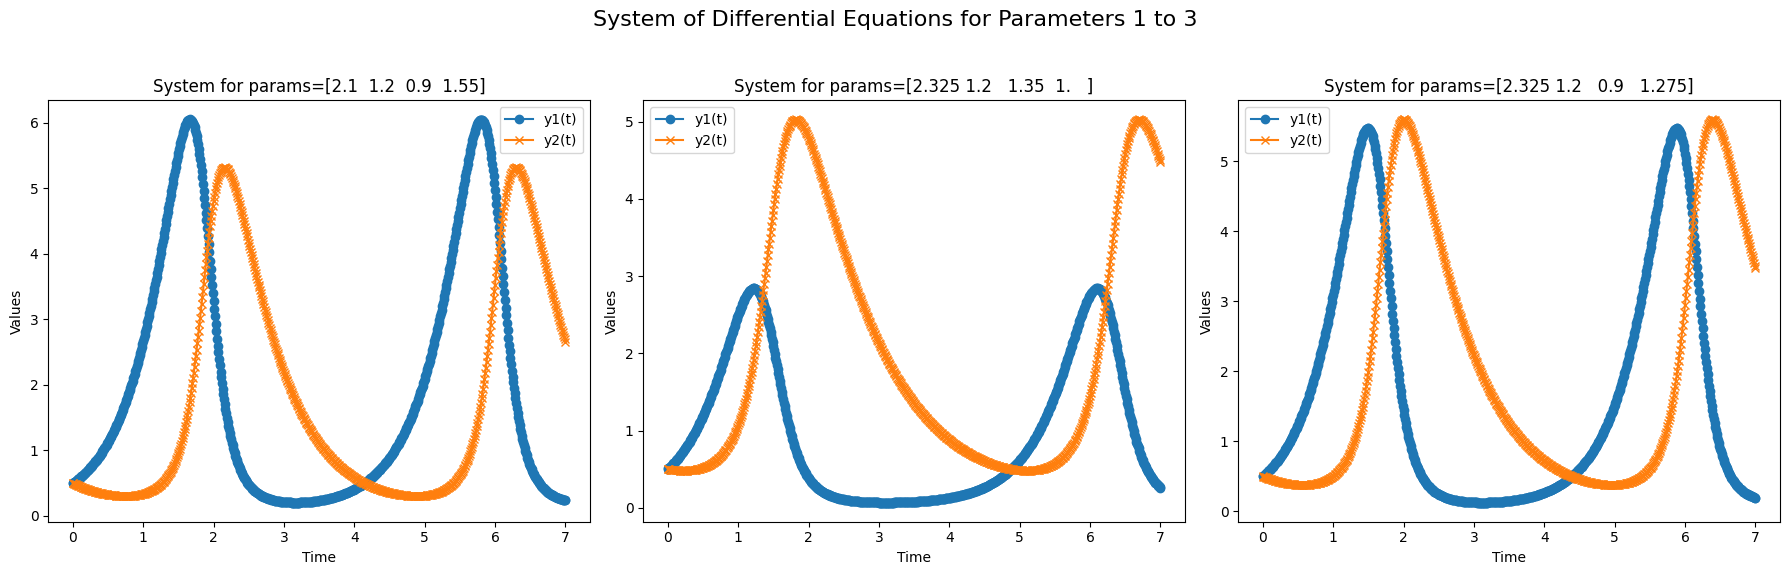

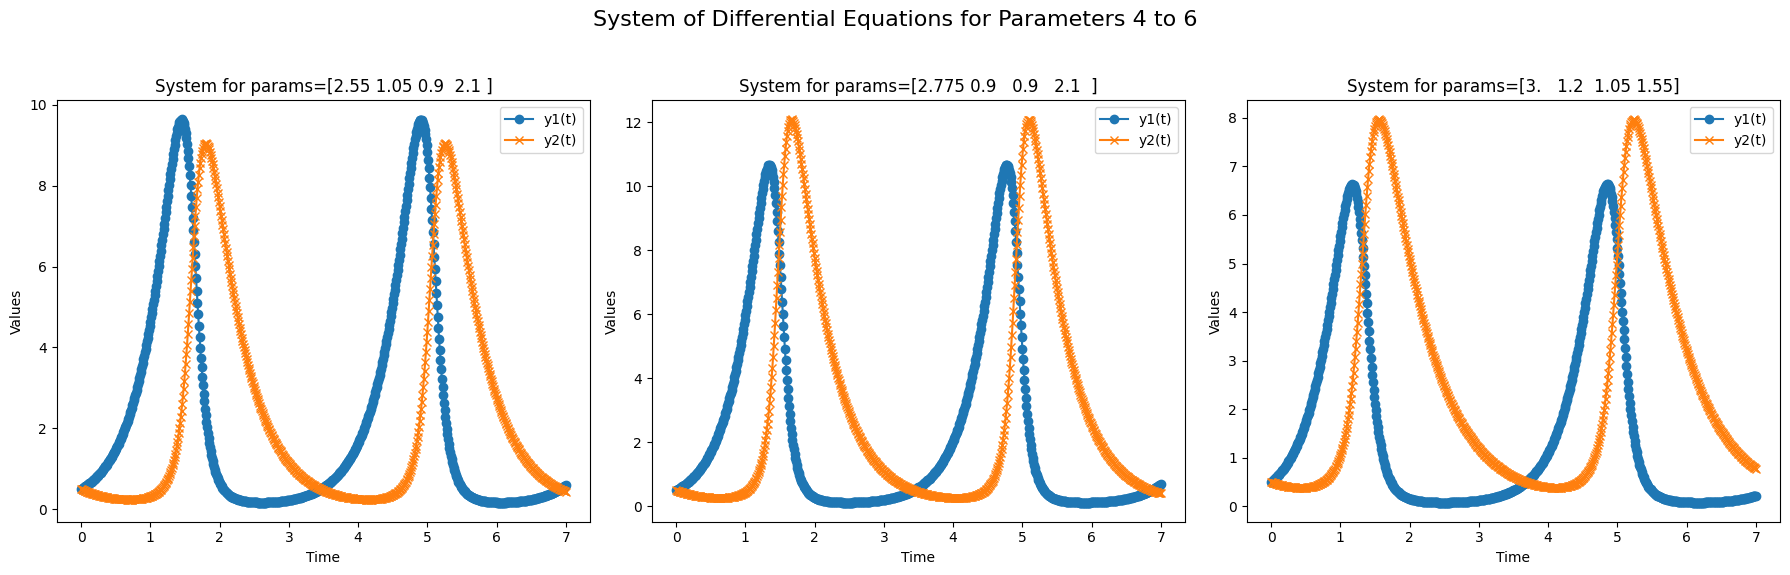

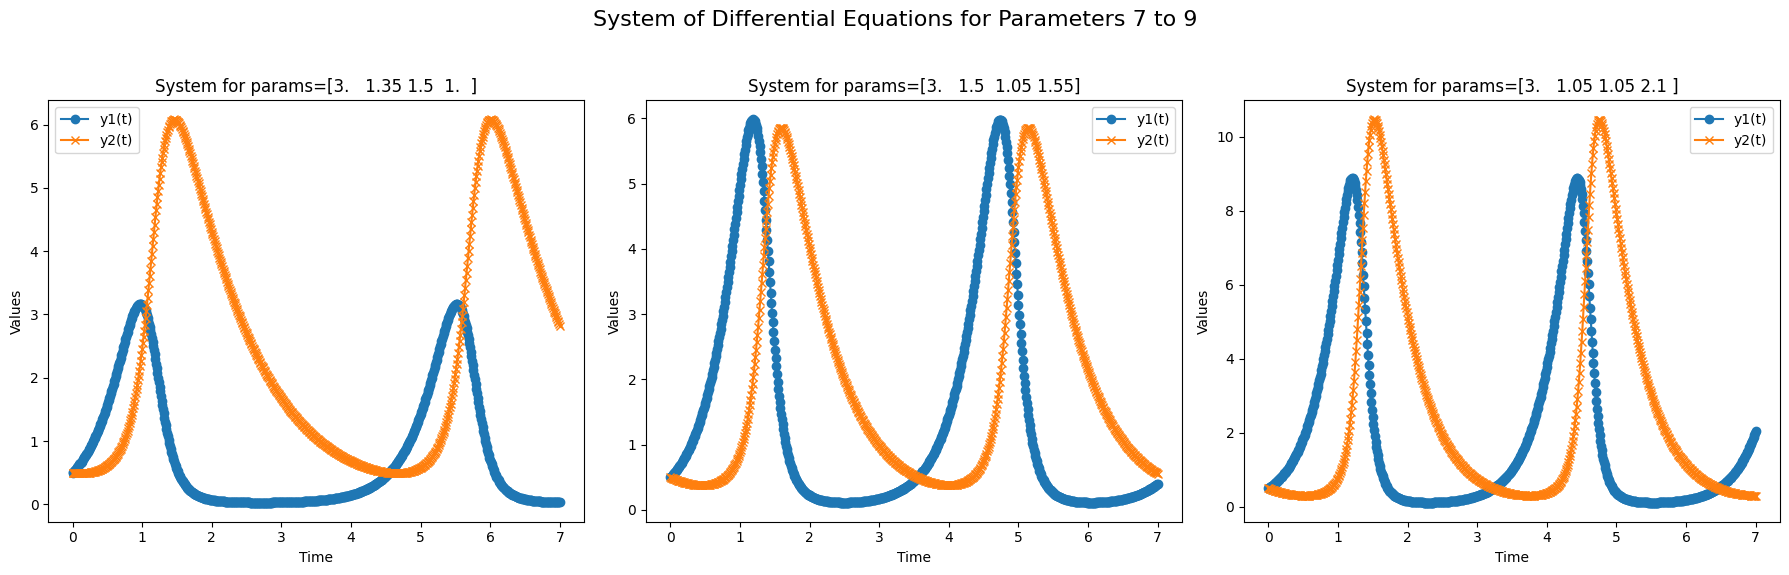

In [20]:
solver_valHF.plot_results()

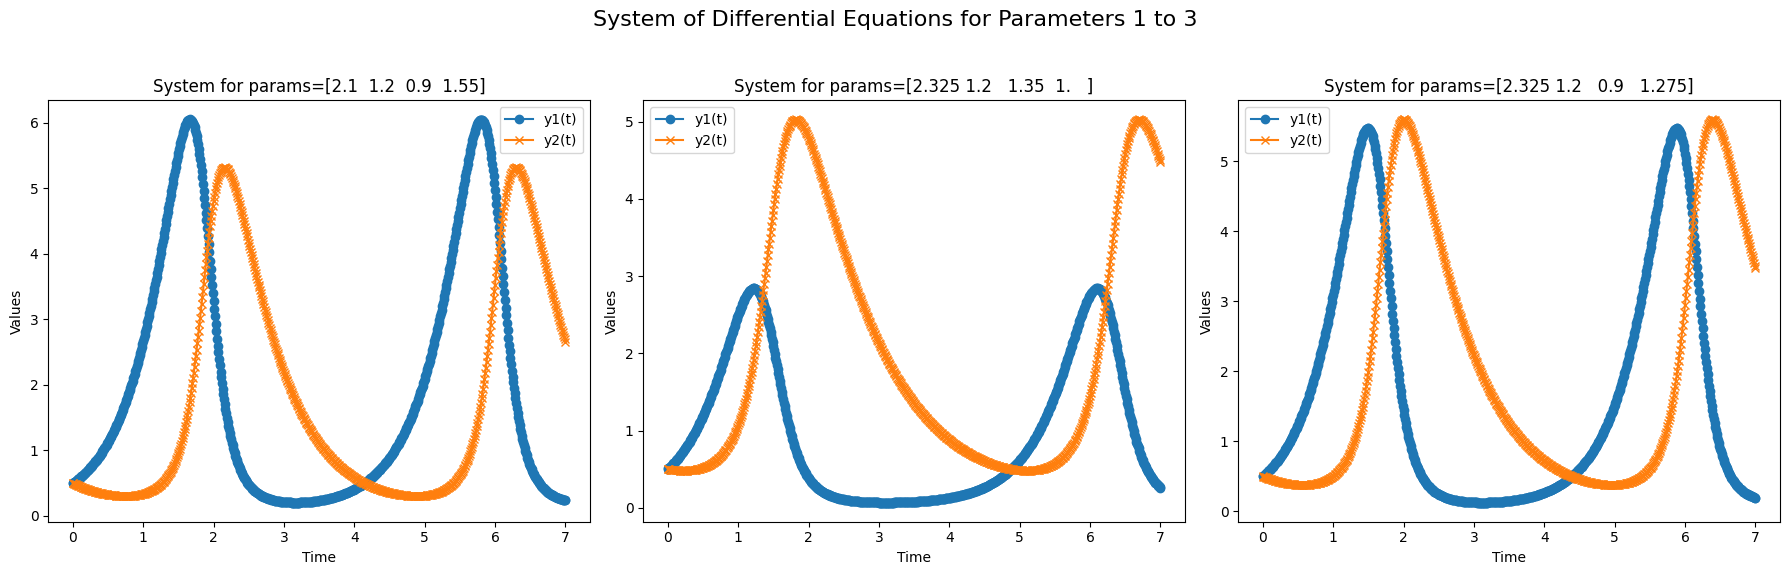

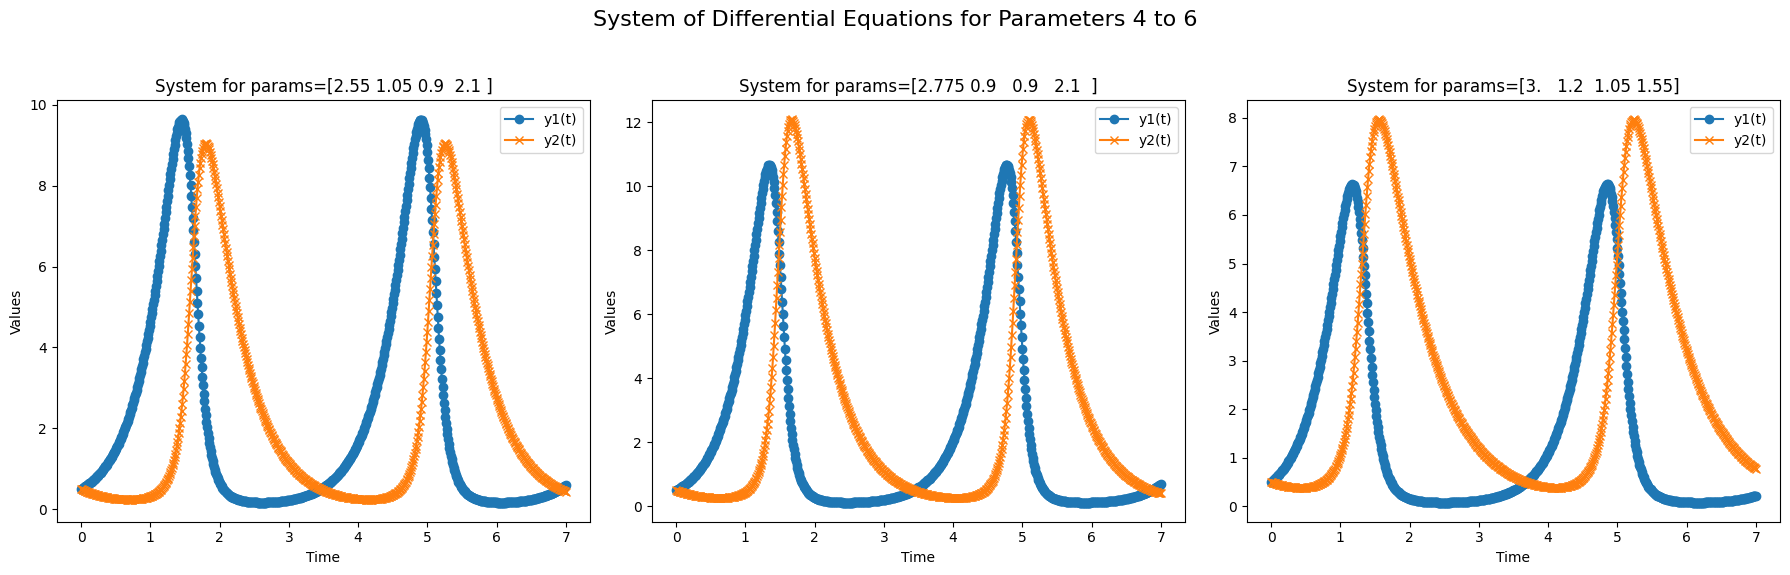

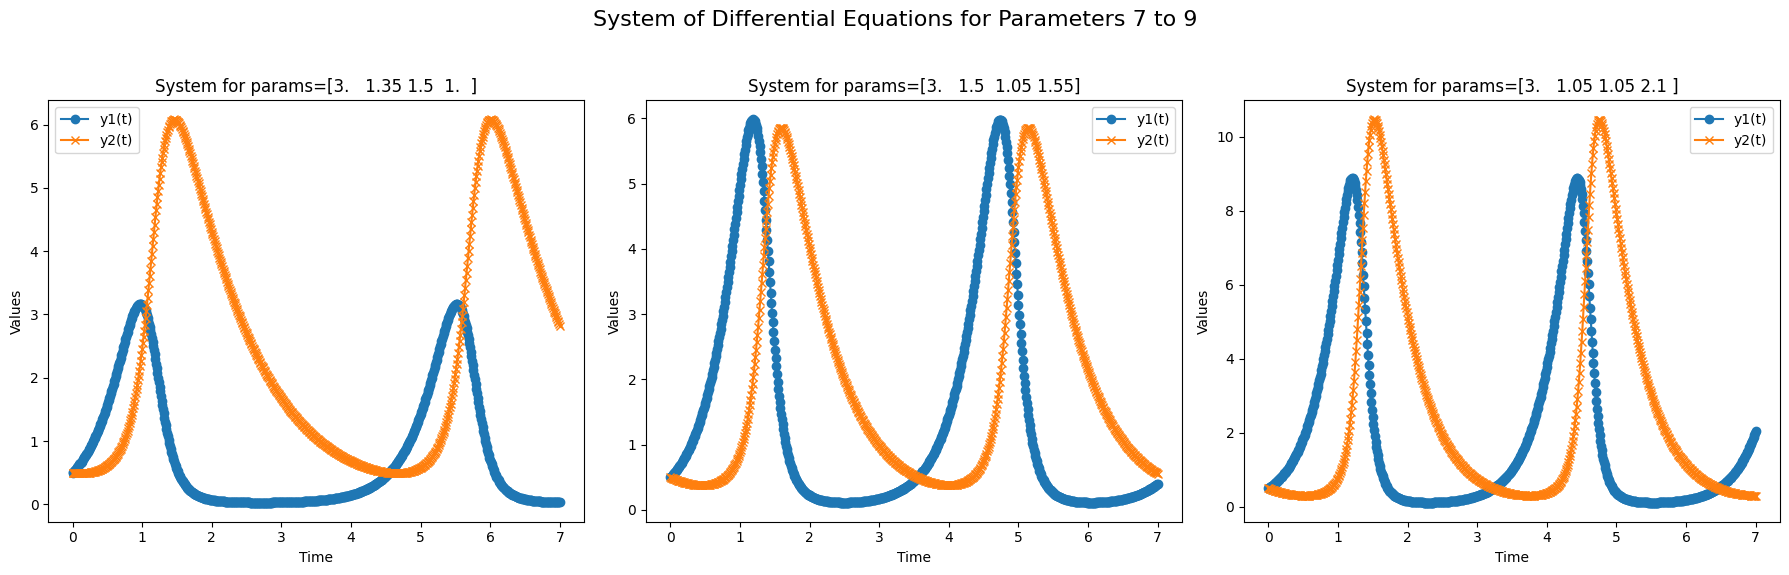

In [21]:
solver_HF.plot_results()

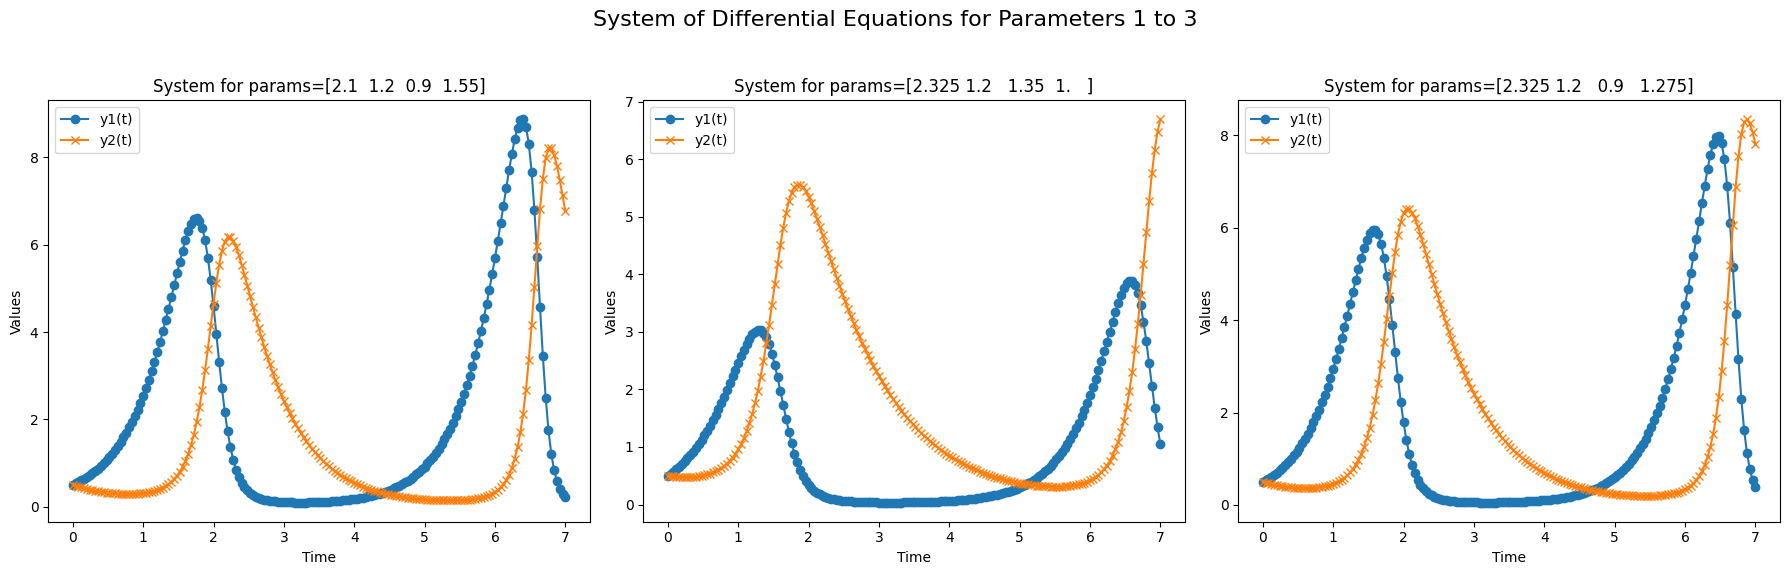

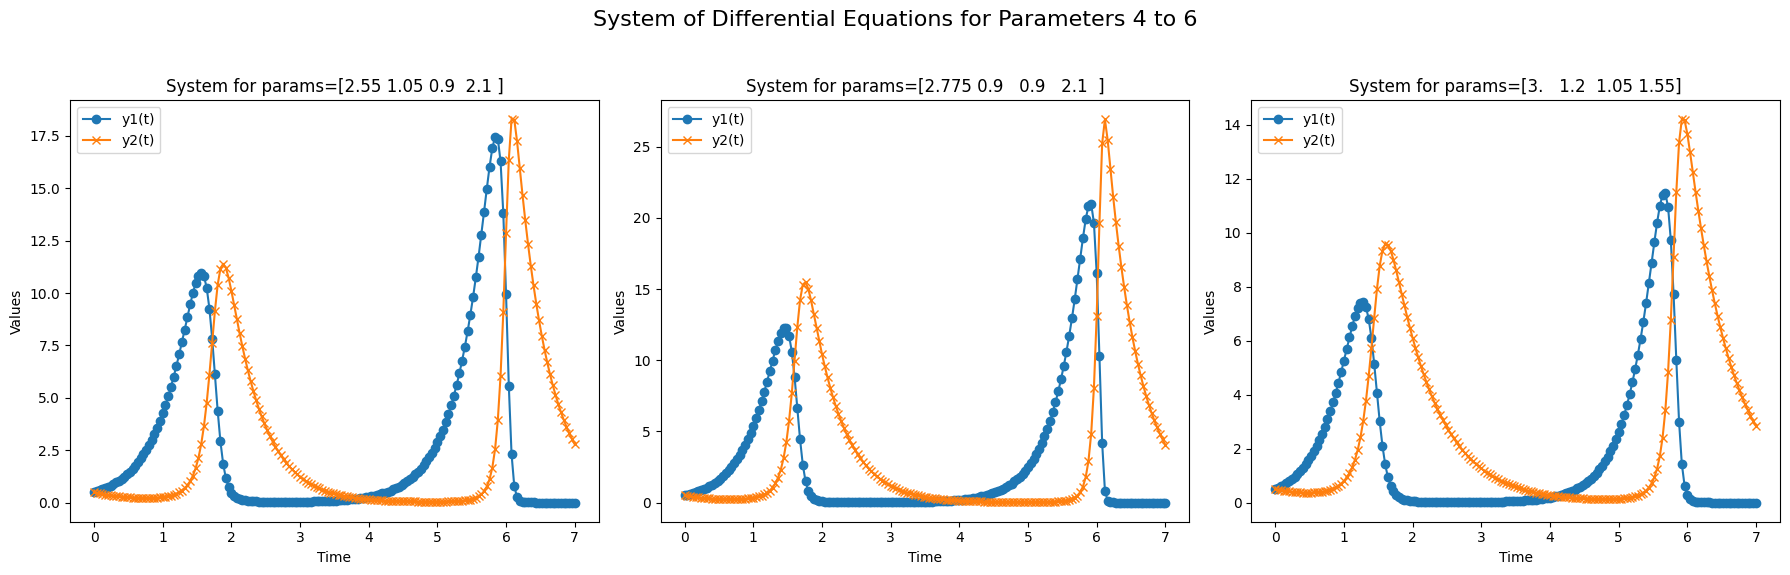

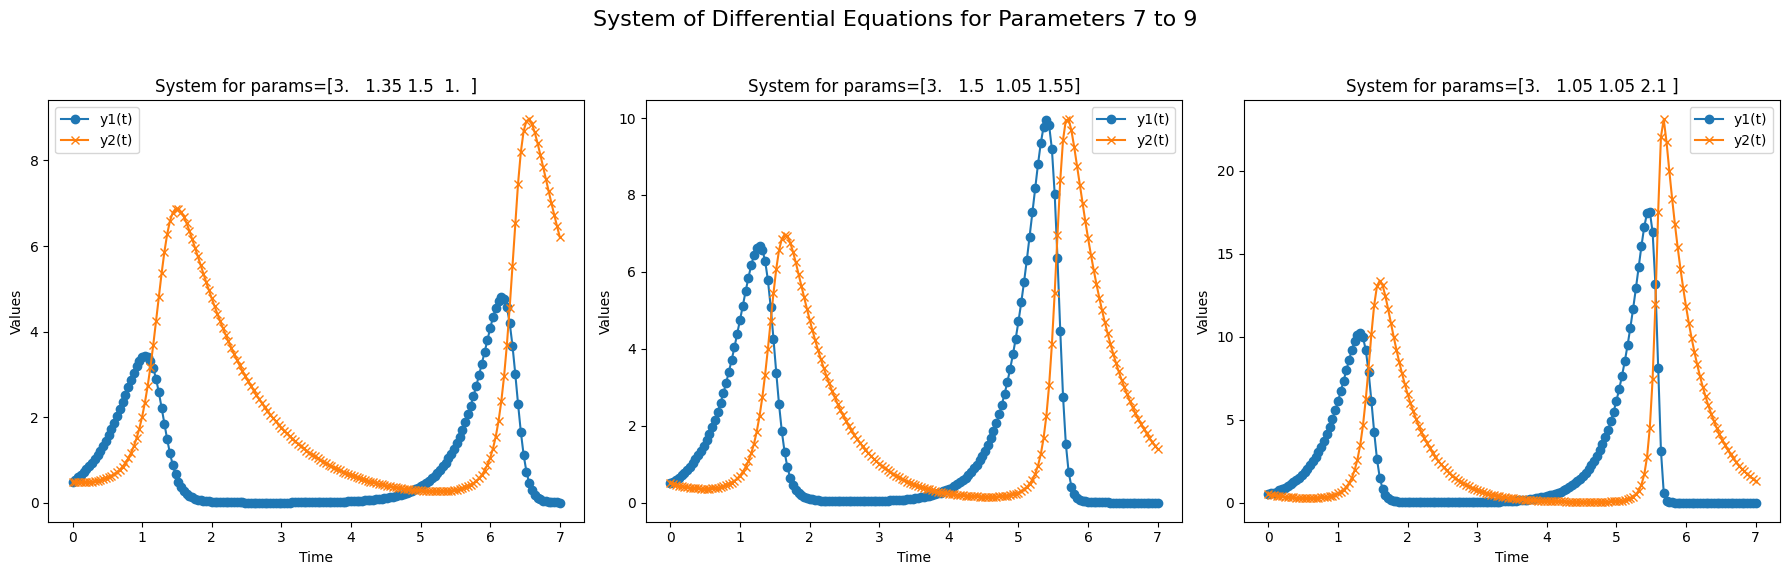

In [22]:
solver_LF.plot_results()

In [23]:
# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_HF.shape[0]), np.arange(t_HF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_HF = np.hstack((t_HF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_HF[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_LF.shape[0]), np.arange(t_LF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_LF = np.hstack((t_LF[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_LF[cartesian_product_indices[:, 0]]))


In [24]:
# Create the Cartesian product of the indices
cartesian_product_indices_val = np.array(np.meshgrid(np.arange(mu_valHF.shape[0]), np.arange(t_valHF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_valHF = np.hstack((t_valHF[cartesian_product_indices_val[:, 1]].reshape(-1, 1), mu_valHF[cartesian_product_indices_val[:, 0]]))
#print(combined_vectors)


# Create the Cartesian product of the indices
cartesian_product_indices_val = np.array(np.meshgrid(np.arange(mu_valLF.shape[0]), np.arange(t_valLF.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
x_valLF = np.hstack((t_valLF[cartesian_product_indices_val[:, 1]].reshape(-1, 1), mu_valLF[cartesian_product_indices_val[:, 0]]))

In [10]:
x_LF.shape

(1584, 5)

In [25]:
y_HF=np.array(y_HF).reshape(-1, solver_HF.get_dim())
y_LF=np.array(y_LF).reshape(-1, solver_LF.get_dim())


In [26]:
y_valHF=np.array(y_valHF).reshape(-1, solver_valHF.get_dim())
y_valLF=np.array(y_valLF).reshape(-1, solver_valLF.get_dim())

In [13]:
y_HF.shape

(6309, 2)

In [14]:
x_HF.shape

(6309, 5)

In [27]:
n_LF=700
indices_LF = np.random.permutation(x_LF.shape[0])[:n_LF]

n_Single=1500
indices_Single = np.random.permutation(x_HF.shape[0])[:n_Single]

n_HF=2000
indices_HF = np.random.permutation(x_HF.shape[0])[:n_HF]


n_valLF=500
indices_valLF = np.random.permutation(x_valLF.shape[0])[:n_valLF]

n_valSingle=1250
indices_valSingle = np.random.permutation(x_valHF.shape[0])[:n_valSingle]

n_valHF=1700
indices_valHF = np.random.permutation(x_valHF.shape[0])[:n_valHF]

[I 2024-08-21 00:14:39,349] A new study created in RDB with name: no-name-53a67995-9f70-4b36-b09c-9e15874bf286
[I 2024-08-21 00:16:11,479] Trial 0 finished with value: 6.33816547298394 and parameters: {'nodes': 18, 'l2weight': 0.0007573546033092677, 'lr': 0.0003088860078553865, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 6.33816547298394.
[I 2024-08-21 00:16:12,239] Trial 6 finished with value: 9.502397201965369 and parameters: {'nodes': 16, 'l2weight': 0.0008089140331808877, 'lr': 0.00017529586001563586, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 0 with value: 6.33816547298394.
[I 2024-08-21 00:16:12,685] Trial 3 finished with value: 11.671655878621788 and parameters: {'nodes': 23, 'l2weight': 0.03839363588896035, 'lr': 0.07103080268308619, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 0 with value: 6.33816547298394.
[I 2024-08-21 00:16:13,359] Trial 1 finished with value: 2.5637087159368277 and parameters: {'no

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.002086252170990476,
 'lr': 0.0006684072410663945,
 'nodes': 19,
 'opt': 'Adam'}
The function training took 32.018005 seconds.


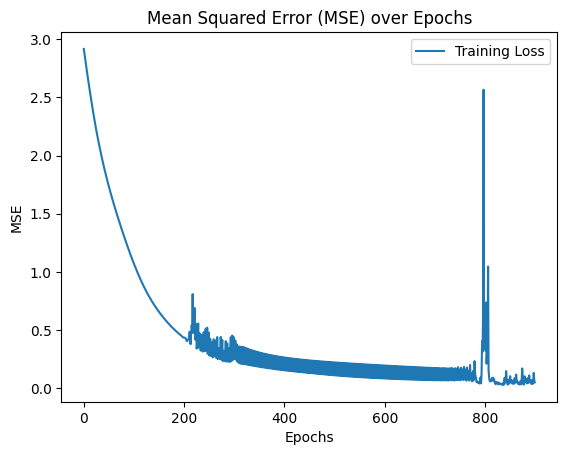

[I 2024-08-21 00:18:47,141] A new study created in RDB with name: no-name-75368fd1-fec3-4cf0-902c-8fce06c6f1fb
[I 2024-08-21 00:19:28,847] Trial 1 finished with value: 0.10110248380045272 and parameters: {'nodes': 10, 'l2weight': 0.0004132743217181665, 'lr': 0.003180630087514021, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 1 with value: 0.10110248380045272.
[I 2024-08-21 00:19:29,957] Trial 2 finished with value: 0.1915840314507156 and parameters: {'nodes': 28, 'l2weight': 0.0022988201114623862, 'lr': 0.010013028558867362, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.10110248380045272.
[I 2024-08-21 00:19:30,981] Trial 3 finished with value: 0.2614076927524913 and parameters: {'nodes': 4, 'l2weight': 0.0005813645757277213, 'lr': 0.07698579339553334, 'kernel_init': 'uniform', 'opt': 'Adamax'}. Best is trial 1 with value: 0.10110248380045272.
[I 2024-08-21 00:19:32,532] Trial 8 finished with value: 0.38669520664137835 and parameters:

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.0003560479678957748,
 'lr': 0.0067446665215358595,
 'nodes': 6,
 'opt': 'Adam'}
The function training took 15.401604 seconds.


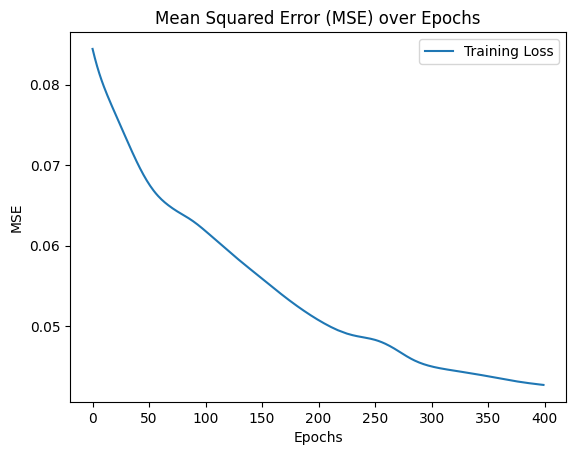

[I 2024-08-21 00:20:52,830] A new study created in RDB with name: no-name-23349682-37e8-460e-8a7e-99b303e5711d
[I 2024-08-21 00:22:01,425] Trial 1 finished with value: 2.3466696417208706 and parameters: {'nodes': 17, 'l2weight': 0.0010481543161758792, 'lr': 0.00019138601330799933, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 1 with value: 2.3466696417208706.
[I 2024-08-21 00:22:03,194] Trial 2 finished with value: 0.1044455775356187 and parameters: {'nodes': 33, 'l2weight': 0.02770453503044079, 'lr': 0.04223924828102854, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}. Best is trial 2 with value: 0.1044455775356187.
[I 2024-08-21 00:22:03,943] Trial 6 finished with value: 0.03681882290762279 and parameters: {'nodes': 57, 'l2weight': 0.009231443655889378, 'lr': 0.0035796617416100052, 'kernel_init': 'glorot_uniform', 'opt': 'Adamax'}. Best is trial 4 with value: 0.024353281071069648.
[I 2024-08-21 00:22:03,965] Trial 4 finished with value: 0.024353281071069648 and param

New parameters identified during HPO:
{'kernel_init': 'glorot_uniform',
 'l2weight': 0.00014877179504142786,
 'lr': 0.03518287483245958,
 'nodes': 18,
 'opt': 'Adam'}
The function training took 41.335631 seconds.


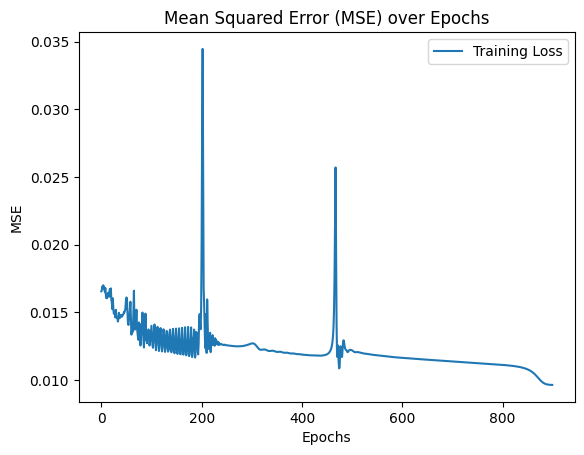

Test MSE: 0.09475535017245325
R^2: 0.9788655569727415


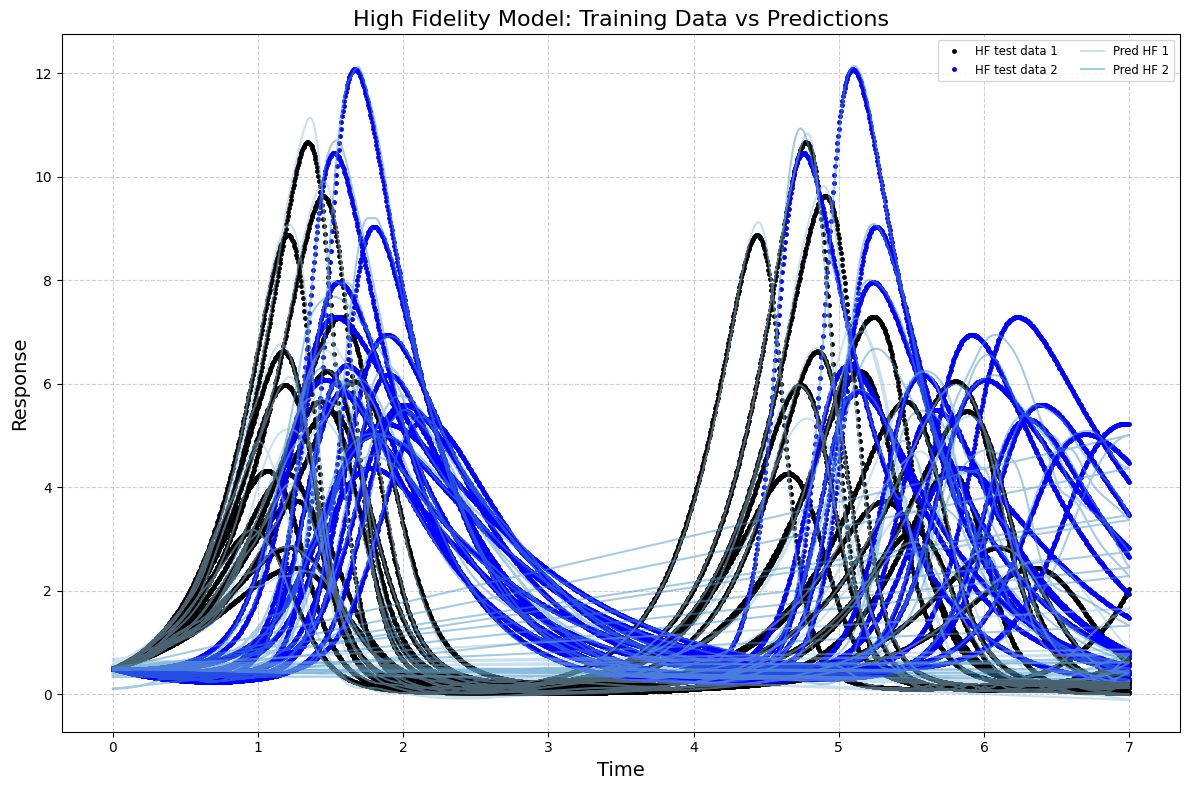

In [16]:




N=[1000,500,1000]
#n=[500,1000]
n=[75,150,200]

names = ['LF','Single', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params_single={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228,  
             'opt': 'Adamax'}

best_params={'kernel_init': 'uniform', 
             'l2weight': 0.005395541657336886, 
             'lr': 0.0025412188591473228, 
             'nodes': 12.0, 
             'opt': 'Adamax'}

params_NN=[bestLF_params,best_params_single, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_Single,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:],  y_HF[indices_Single,:],y_HF[indices_HF,:]],
    "data_val": [x_valLF[indices_valLF,:],x_valHF[indices_valSingle,:],x_valHF[indices_valHF,:]],
    "output_val": [y_valLF[indices_valLF,:],  y_valHF[indices_valSingle,:],y_valHF[indices_valHF,:]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": True,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:16,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=7.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,solver_test.get_dim())[:, 0], 'k.', label='HF test data 1', markersize=5)  # Nero
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1,solver_test.get_dim())[:, 1], 'b.', label='HF test data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

In [31]:
N=[1000,500,1000]
#n=[500,1000]
n=[75,150,200]

names = ['LF','Single', 'HF']

# parameters 
bestLF_params = {'kernel_init': 'glorot_uniform',
 'l2weight': 0.002086252170990476,
 'lr': 0.0006684072410663945,
 'nodes': 19,
 'opt': 'Adam'}
best_params_single={'kernel_init': 'glorot_uniform',
 'l2weight': 0.0003560479678957748,
 'lr': 0.0067446665215358595,
 'nodes': 6,
 'opt': 'Adam'}

best_params={'kernel_init': 'glorot_uniform',
 'l2weight': 0.00014877179504142786,
 'lr': 0.03518287483245958,
 'nodes': 18,
 'opt': 'Adam'}
params_NN=[bestLF_params,best_params_single, best_params]

# collection of the parameters
definition_2steps = {
    "network_type": "3step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF[indices_LF,:],x_HF[indices_Single,:],x_HF[indices_HF,:]],
    "output_train": [y_LF[indices_LF,:],  y_HF[indices_Single,:],y_HF[indices_HF,:]],
    "data_val": [x_valLF[indices_valLF,:],x_valHF[indices_valSingle,:],x_valHF[indices_valHF,:]],
    "output_val": [y_valLF[indices_valLF,:],  y_valHF[indices_valSingle,:],y_valHF[indices_valHF,:]],
    "N": N,
    "n": n,
    "train": False,
    "do_HPO": False,
    "verbose": False
}


In [34]:
def create_factory():
    return [NetworkFactory.build_network(**definition_2steps) for i in range(10)]

In [35]:
mem_values=[]
time_values=[]
for _ in range(10):
    mem_usage=memory_usage(create_factory, interval=0.01)
    mem_values.append(max(mem_usage))

    

In [37]:
print(mem_values)

[530.19921875, 510.125, 510.26953125, 510.28125, 510.2890625, 510.296875, 510.3046875, 510.3203125, 510.34375, 510.3515625]


The function training took 59.345930 seconds.


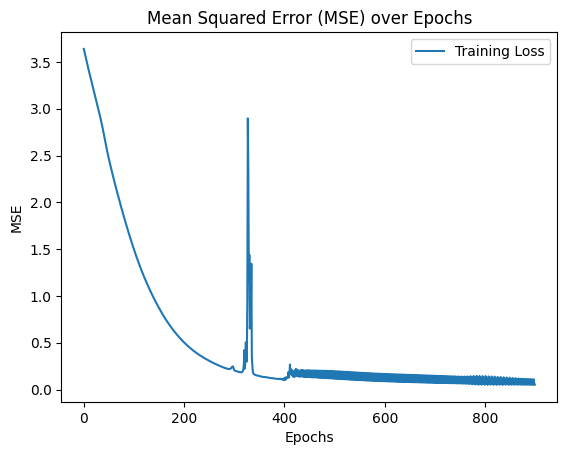

The function training took 29.914341 seconds.


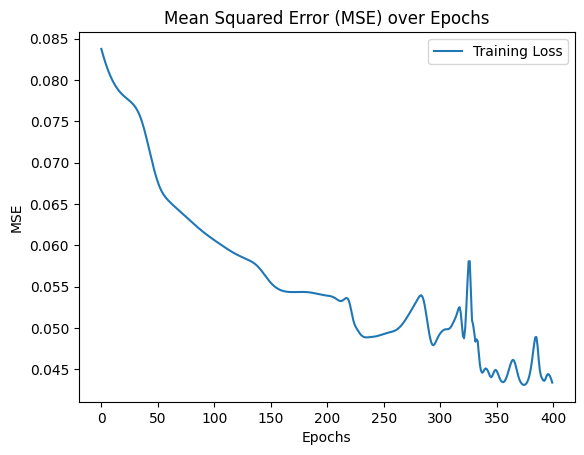

KeyboardInterrupt: 

In [29]:




final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System2()
params_values_test = combinations_array[0:20,:]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=7.0, params=params_values_test, h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test_4params.h5')



# Create the Cartesian product of the indices
cartesian_product_indices = np.array(np.meshgrid(np.arange(mu_test.shape[0]), np.arange(t_test.shape[0]))).T.reshape(-1, 2)

# Extract the respective elements from the original vectors
datatest = np.hstack((t_test[cartesian_product_indices[:, 1]].reshape(-1, 1), mu_test[cartesian_product_indices[:, 0]]))
#print(combined_vectors)


y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,solver_test.get_dim()))


plt.figure(figsize=(12, 8))

# Plotting the training data with darker markers
plt.plot(x_HF[:, 0], y_HF[:, 0], 'k.', label='HF training data 1', markersize=5)  # Nero
plt.plot(x_HF[:, 0], y_HF[:, 1], 'b.', label='HF training data 2', markersize=5)  # Blu scuro

# Plotting the prediction data with lighter, less fluorescent colors
for i in range(y_test_pred.shape[1]):
    plt.plot(datatest[:, 0], y_test_pred[:, i], '-', 
             color=plt.cm.Blues(0.4 + 0.4 * i / y_test_pred.shape[1]),  # Gamma di blu meno vividi
             alpha=0.5, label=f'Pred HF {i+1}', linewidth=1.5)  # Trasparenza ridotta e linee più sottili

# Adding grid to the plot
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to the axes
plt.xlabel('Time', fontsize=14)
plt.ylabel('Response', fontsize=14)

# Enhancing the title
plt.title('High Fidelity Model: Training Data vs Predictions', fontsize=16)

# Improving the legend
plt.legend(loc='best', fontsize='small', ncol=2)

# Adjusting the layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

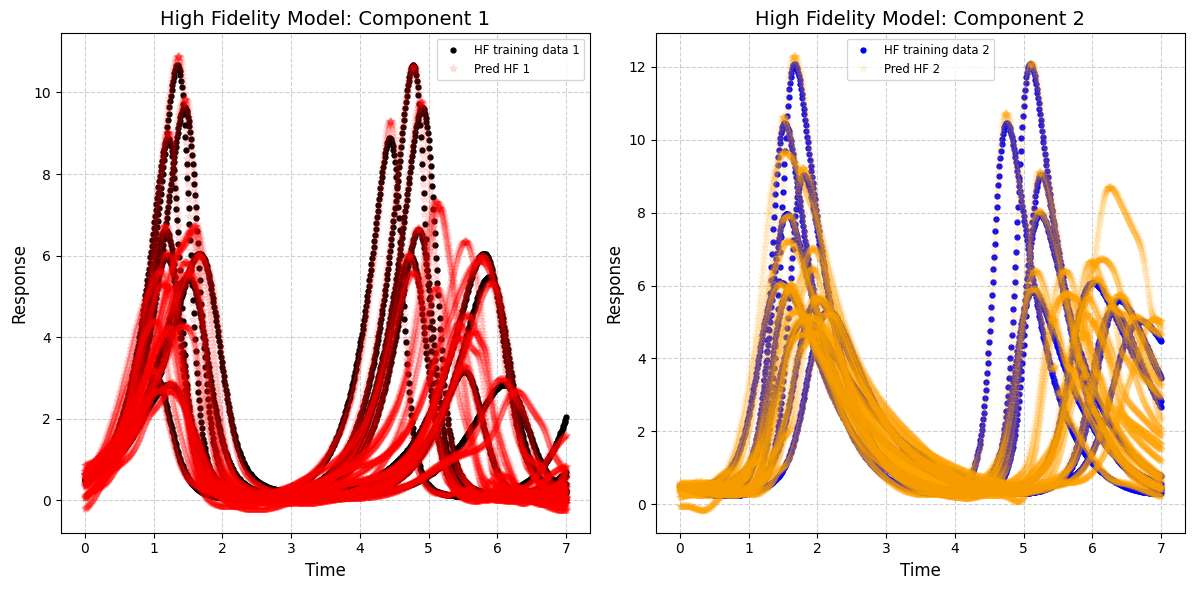

In [14]:
components = ['Component 1', 'Component 2']
colors_training = ['k', 'b', 'g']  # Nero, Blu scuro, Verde scuro
colors_pred = ['r', 'orange', 'purple']  # Rosso, Arancione, Viola

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(2):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.plot(x_HF[:, 0], y_HF[:, i], f'{colors_training[i]}.', label=f'HF training data {i + 1}', markersize=7)

    # Plotting the prediction data for the i-th component
    plt.plot(datatest[:, 0], y_test_pred[:, i], '*', 
             color=colors_pred[i], alpha=0.1, label=f'Pred HF {i + 1}', linewidth=3)
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

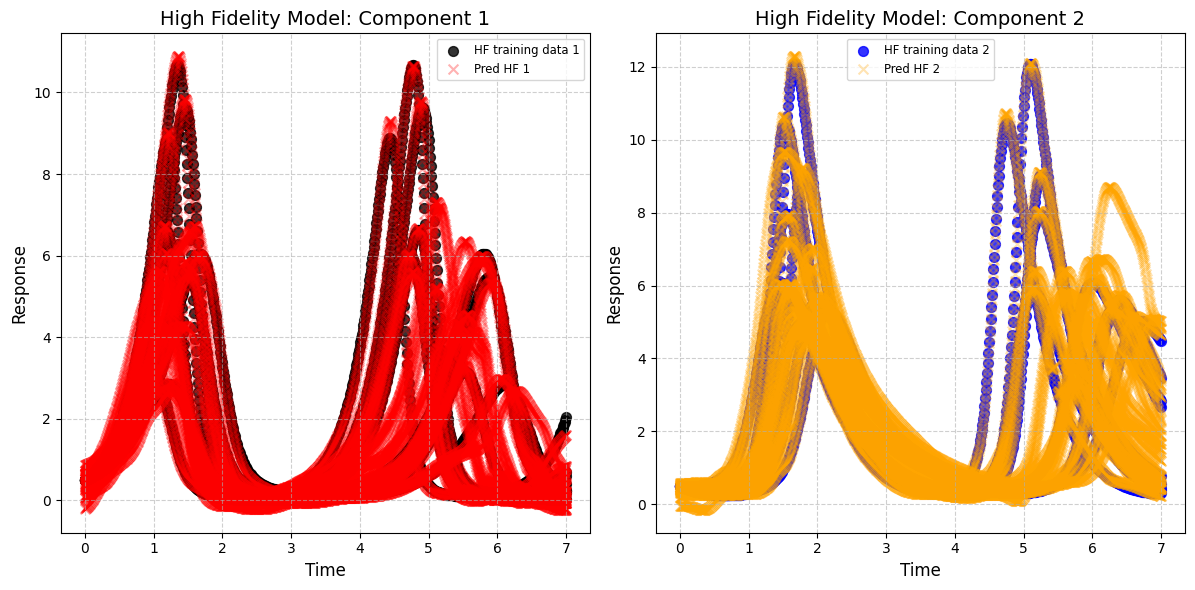

In [18]:
components = ['Component 1', 'Component 2']
colors_training = ['k', 'b']  # Nero, Blu scuro
colors_pred = ['r', 'orange']  # Rosso, Arancione

plt.figure(figsize=(18, 6))

# Loop through each component to create a separate plot
for i in range(2):
    plt.subplot(1, 3, i + 1)  # Create a subplot (1 row, 3 columns)
    
    # Plotting the training data for the i-th component
    plt.scatter(x_HF[0:int(x_HF.shape[0]), 0], y_HF[0:int(y_HF.shape[0]), i], color=colors_training[i], label=f'HF training data {i + 1}', s=50, marker='o', alpha=0.8)
    
    # Plotting the prediction data for the i-th component with adjusted transparency and different marker
    plt.scatter(datatest[0:int(datatest.shape[0]), 0], y_test_pred[0:int(y_test_pred.shape[0]), i], color=colors_pred[i], alpha=0.3, label=f'Pred HF {i + 1}', s=50, marker='x')
    
    # Adding grid, labels, and title
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Response', fontsize=12)
    plt.title(f'High Fidelity Model: {components[i]}', fontsize=14)
    
    # Add a legend
    plt.legend(loc='best', fontsize='small')

# Adjust the layout and show the plot
plt.tight_layout()
plt.show()

# Bayesian

In [17]:
print(np.unique(datatest[:,1]))
print(np.unique(datatest[:,2]))
print(np.unique(datatest[:,3]))
print(np.unique(datatest[:,4]))

[2.1   2.325 2.55  2.775 3.   ]
[0.9  1.05 1.2  1.35 1.5 ]
[0.9  1.05 1.2  1.35 1.5 ]
[1.    1.275 1.55  1.825 2.1  ]


In [17]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

In [19]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,80)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( .5,5.)
rwmh_scaling_bounds =  (0.5,3.)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 45
burnin = 30
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,7.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        subsampling_rate=2,
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model,
                        levels=3, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=15)

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------


InvalidArgumentError: Graph execution error:

Detected at node functional_1/dense_1/Tanh defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start

  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\tornado\platform\asyncio.py", line 205, in start

  File "c:\Users\Giacomo\miniconda3\Lib\asyncio\base_events.py", line 639, in run_forever

  File "c:\Users\Giacomo\miniconda3\Lib\asyncio\base_events.py", line 1985, in _run_once

  File "c:\Users\Giacomo\miniconda3\Lib\asyncio\events.py", line 88, in _run

  File "c:\Users\Giacomo\miniconda3\Lib\site-packages\ipykernel\kernelbase.py", line 54

In [17]:
# Define inputs
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sd_noise = (0.05,0.1)
n_data = (30,50)
parameters =np.array([3.,1.35,1.05,1.])

iterations = 100
burnin = 20
number_chains = 2
algo = "MH"

proposal_sd = (.5,4.)    # più piccolo, altrimenti scappa da previsione 
scaling = (.5,3.)
adapt = True




module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

#x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

best_estimate, best_error, best_sd_noise, best_proposal_sd, best_n_data, best_scale=HPO_cuqi(
    data= x_HF,
    Yhf=y_HF,
    mean_prior= mean_prior,
    parameters=parameters,
    domain=(0.,7.),
    iterations= iterations,
    burn_in= burnin,
    cov_prior= cov_prior,
    sd_noise=sd_noise,
    proposal_sd= proposal_sd,
    n_data=n_data,
    scale= scaling,
    adapt=adapt,
    number_chains= number_chains,
    algo=algo,
    fwd_model=final_model,
    parallel=True,
    init_points = 4,
    n_iter = 15
) 


|   iter    |  target   |  n_data   | propos... |   scale   | sd_noise  |
-------------------------------------------------------------------------


TypeError: object of type 'int' has no len()

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-23 12:03:47,151	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.700  0.165   2.475    2.979      0.053    0.039       9.0      19.0   
x1  1.046  0.054   0.967    1.144      0.026    0.020       4.0      11.0   
x2  1.472  0.108   1.290    1.627      0.041    0.030       7.0      10.0   
x3  1.704  0.172   1.415    2.044      0.068    0.052       6.0      44.0   

    r_hat  
x0   1.19  
x1   1.42  
x2   1.20  
x3   1.28  
Estimated values are [2.7   1.046 1.472 1.704]
The difference between estimated values [0.3   0.304 0.422 0.704]



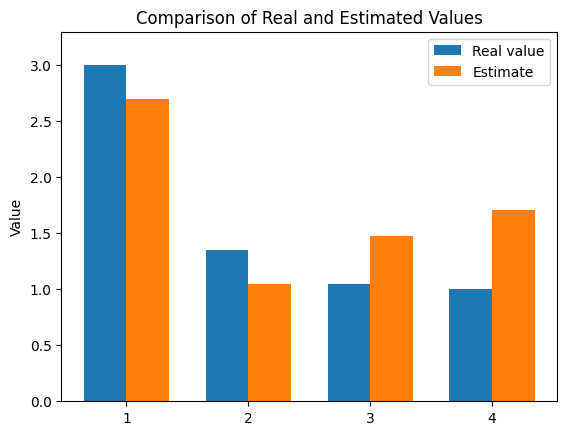

The function param_inverse took 2012.252197 seconds.
| 1         | -1.431    | 48.73     | 2.877     | 3.794     | 0.3997    |
Sampling 2 chains in parallel


2024-08-23 12:35:50,012	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.941  0.053   2.866    3.021      0.035    0.029       2.0       2.0   
x1  1.366  0.023   1.331    1.386      0.016    0.013       2.0       2.0   
x2  1.218  0.039   1.181    1.284      0.026    0.021       3.0       2.0   
x3  1.521  0.014   1.500    1.542      0.009    0.007       2.0       6.0   

    r_hat  
x0   4.93  
x1   6.87  
x2   6.87  
x3   6.87  
Estimated values are [2.941 1.366 1.218 1.521]
The difference between estimated values [0.059 0.016 0.168 0.521]



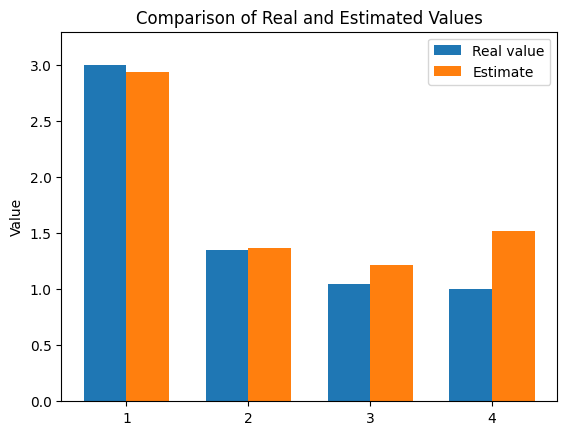

The function param_inverse took 1963.607818 seconds.
| 2         | -0.7125   | 37.8      | 0.89      | 0.7614    | 0.4665    |
Sampling 2 chains in parallel


2024-08-23 13:09:01,448	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(


(RemoteMLDAChain pid=1197256) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteMLDAChain pid=1197256)   return np.exp(proposal_link.posterior - previous_link.posterior)
(RemoteMLDAChain pid=1299904) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(RemoteMLDAChain pid=1299904)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 2x across cluster]


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.922  0.437   2.485    3.359      0.308    0.261       2.0       2.0   
x1  1.126  0.207   0.919    1.333      0.146    0.123       2.0       2.0   
x2  1.203  0.487   0.716    1.690      0.344    0.291       2.0       2.0   
x3  1.575  0.122   1.453    1.697      0.086    0.073       2.0       2.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Estimated values are [2.922 1.126 1.203 1.575]
The difference between estimated values [0.078 0.224 0.153 0.575]



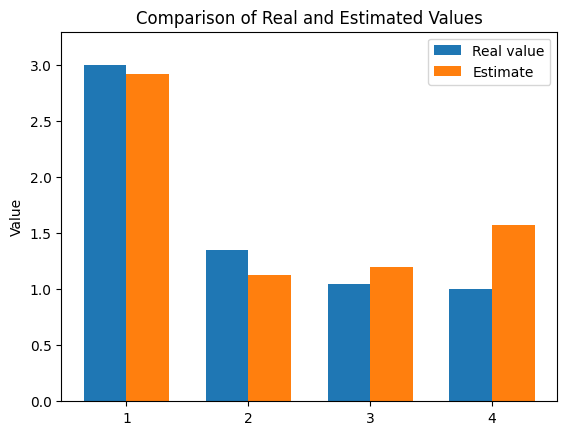

The function param_inverse took 2643.259994 seconds.
| 3         | -0.9126   | 60.06     | 2.27      | 0.5926    | 0.4925    |
Sampling 2 chains in parallel


2024-08-23 13:53:37,936	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.857  0.036   2.767    2.866      0.016    0.012       3.0       5.0   
x1  1.215  0.020   1.168    1.226      0.009    0.006       4.0       5.0   
x2  1.342  0.056   1.304    1.467      0.024    0.018       4.0       3.0   
x3  1.583  0.068   1.519    1.702      0.046    0.038       2.0       2.0   

    r_hat  
x0   3.00  
x1   2.55  
x2   2.55  
x3   3.32  
Estimated values are [2.857 1.215 1.342 1.583]
The difference between estimated values [0.143 0.135 0.292 0.583]



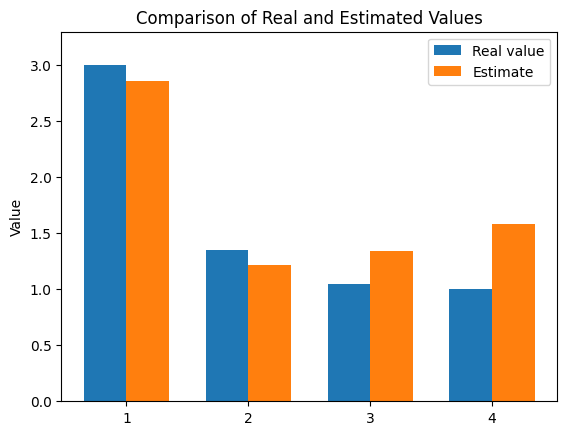

The function param_inverse took 2187.821378 seconds.
| 4         | -1.009    | 71.62     | 1.031     | 1.318     | 0.2959    |
Sampling 2 chains in parallel


2024-08-23 14:30:41,422	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.052  0.112   2.909    3.151      0.078    0.065       2.0       2.0   
x1  1.587  0.036   1.526    1.616      0.025    0.021       2.0       2.0   
x2  1.201  0.128   1.072    1.334      0.090    0.076       2.0       2.0   
x3  1.493  0.051   1.447    1.565      0.035    0.030       2.0       2.0   

    r_hat  
x0   3.37  
x1   3.02  
x2   2.52  
x3   3.02  
Estimated values are [3.052 1.587 1.201 1.493]
The difference between estimated values [0.052 0.237 0.151 0.493]



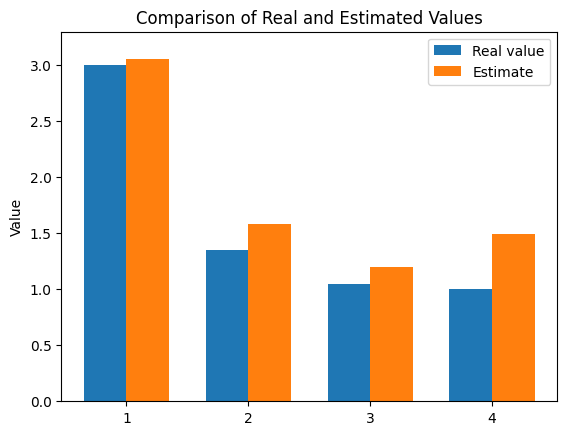

The function param_inverse took 2528.605079 seconds.
| 5         | -0.8297   | 60.03     | 2.313     | 0.6813    | 0.46      |
Sampling 2 chains in parallel


2024-08-23 15:13:16,251	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.251  0.120   2.224    2.224      0.035    0.026      12.0      12.0   
x1  1.001  0.000   1.001    1.001      0.000    0.000      12.0    3000.0   
x2  1.749  0.060   1.763    1.763      0.018    0.013      12.0    3000.0   
x3  2.129  0.086   2.148    2.148      0.025    0.018      12.0    3000.0   

    r_hat  
x0   1.11  
x1   1.11  
x2   1.11  
x3   1.11  
Estimated values are [2.251 1.001 1.749 2.129]
The difference between estimated values [0.749 0.349 0.699 1.129]



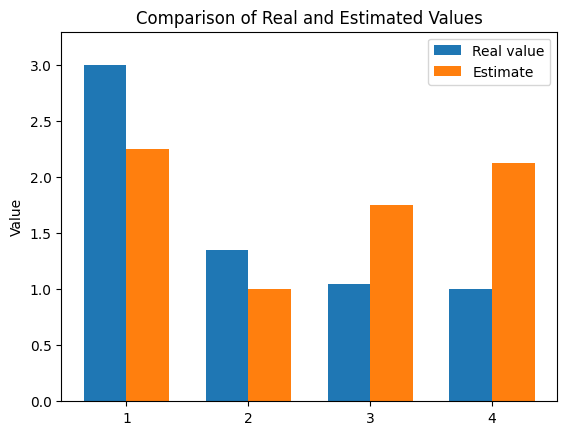

The function param_inverse took 2372.688462 seconds.
| 6         | -2.303    | 37.45     | 0.6264    | 0.6338    | 0.2761    |
Sampling 2 chains in parallel


2024-08-23 15:50:58,340	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.752  0.084   2.611    2.920      0.038    0.029       4.0      33.0   
x1  1.045  0.032   1.005    1.090      0.018    0.014       3.0       3.0   
x2  1.457  0.070   1.350    1.534      0.034    0.026       4.0       6.0   
x3  1.675  0.101   1.524    1.808      0.055    0.044       4.0       6.0   

    r_hat  
x0   1.43  
x1   1.64  
x2   1.55  
x3   1.43  
Estimated values are [2.752 1.045 1.457 1.675]
The difference between estimated values [0.248 0.305 0.407 0.675]



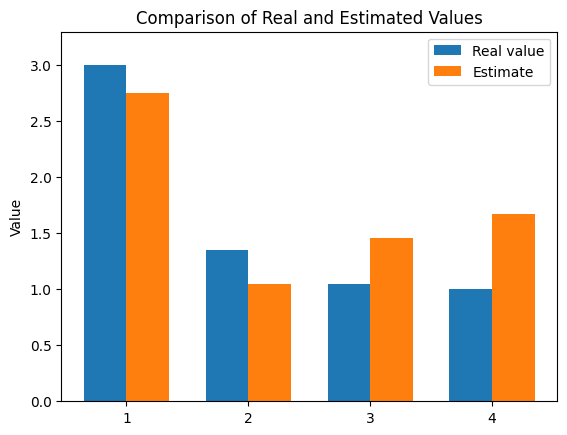

The function param_inverse took 2156.071807 seconds.
| 7         | -1.371    | 78.27     | 1.69      | 3.583     | 0.4893    |
Sampling 2 chains in parallel


2024-08-23 16:27:57,977	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.668  0.174   2.301    2.912      0.029    0.020      38.0      28.0   
x1  1.030  0.098   0.866    1.189      0.043    0.032       6.0      51.0   
x2  1.485  0.100   1.304    1.644      0.013    0.010      60.0      83.0   
x3  1.714  0.168   1.411    2.005      0.030    0.022      34.0      72.0   

    r_hat  
x0   1.07  
x1   1.26  
x2   1.05  
x3   1.03  
Estimated values are [2.668 1.03  1.485 1.714]
The difference between estimated values [0.332 0.32  0.435 0.714]



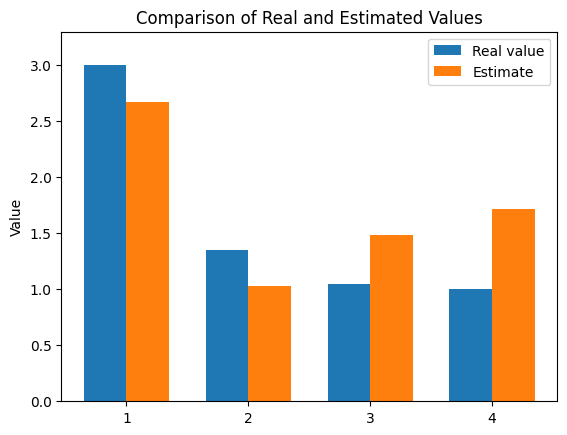

The function param_inverse took 2392.481414 seconds.
| 8         | -1.476    | 56.04     | 1.882     | 4.99      | 0.3336    |
Sampling 2 chains in parallel


2024-08-23 17:06:58,068	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  2.529  0.0   2.529    2.529        0.0      0.0    3000.0    3000.0    NaN
x1  0.920  0.0   0.920    0.920        0.0      0.0    3000.0    3000.0    NaN
x2  1.587  0.0   1.587    1.587        0.0      0.0    3000.0    3000.0    NaN
x3  1.941  0.0   1.941    1.941        0.0      0.0    3000.0    3000.0    NaN
Estimated values are [2.529 0.92  1.587 1.941]
The difference between estimated values [0.471 0.43  0.537 0.941]



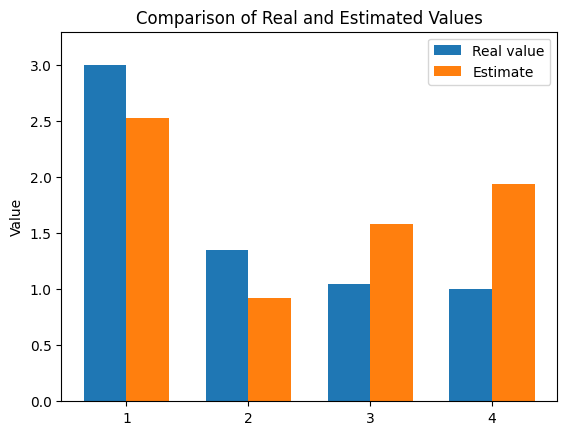

The function param_inverse took 2358.678300 seconds.
| 9         | -1.928    | 37.9      | 0.9903    | 0.8617    | 0.5       |
Sampling 2 chains in parallel


2024-08-23 17:46:39,464	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


KeyboardInterrupt: 

In [18]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,80)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( .5,5.)
rwmh_scaling_bounds =  (0.5,3.)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 4500
burnin = 3000
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,7.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        subsampling_rate=2,
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model,
                        levels=3, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=15)

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-23 09:11:39,047	INFO worker.py:1788 -- Started a local Ray instance.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.681  0.150   2.375    2.904      0.045    0.033      11.0      21.0   
x1  1.093  0.062   1.013    1.195      0.021    0.015      10.0      38.0   
x2  1.485  0.081   1.359    1.631      0.012    0.008      47.0      81.0   
x3  1.706  0.124   1.467    1.914      0.035    0.025      13.0      21.0   

    r_hat  
x0   1.15  
x1   1.16  
x2   1.13  
x3   1.15  
Estimated values are [2.681 1.093 1.485 1.706]
The difference between estimated values [0.319 0.257 0.435 0.706]



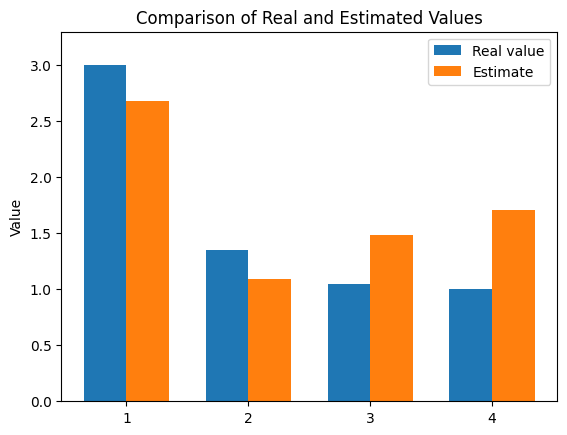

The function param_inverse took 1392.393510 seconds.
| 1         | -1.417    | 48.73     | 2.877     | 3.794     | 0.3997    |
Sampling 2 chains in parallel


2024-08-23 09:35:29,562	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.507  0.167   2.446    2.967      0.075    0.057       5.0       5.0   
x1  1.047  0.039   1.033    1.153      0.017    0.013       5.0       5.0   
x2  1.439  0.163   0.989    1.498      0.074    0.055       5.0       5.0   
x3  1.916  0.142   1.526    1.968      0.064    0.048       5.0       5.0   

    r_hat  
x0   1.37  
x1   1.37  
x2   1.37  
x3   1.37  
Estimated values are [2.507 1.047 1.439 1.916]
The difference between estimated values [0.493 0.303 0.389 0.916]



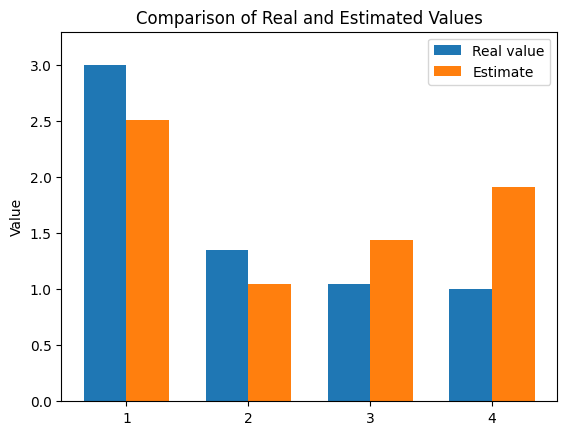

The function param_inverse took 1487.279811 seconds.
| 2         | -1.675    | 37.8      | 0.89      | 0.7614    | 0.4665    |
Sampling 2 chains in parallel


2024-08-23 10:00:10,308	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteMLDAChain pid=1314116) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteMLDAChain pid=1314116)   return np.exp(proposal_link.posterior - previous_link.posterior)


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.004  0.469   2.517    3.471      0.330    0.279       2.0       2.0   
x1  1.244  0.180   1.060    1.424      0.127    0.107       2.0       2.0   
x2  1.214  0.423   0.792    1.651      0.298    0.252       2.0       2.0   
x3  1.526  0.168   1.358    1.692      0.119    0.100       2.0       2.0   

    r_hat  
x0   5.57  
x1   5.57  
x2   5.57  
x3   3.15  
Estimated values are [3.004 1.244 1.214 1.526]
The difference between estimated values [0.004 0.106 0.164 0.526]



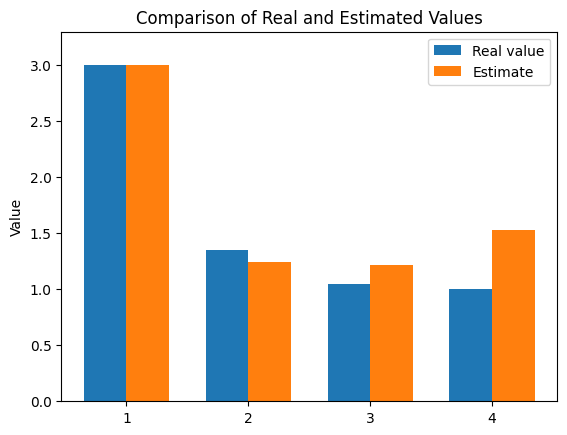

The function param_inverse took 1390.927723 seconds.
| 3         | -0.762    | 60.06     | 2.27      | 0.5926    | 0.4925    |
Sampling 2 chains in parallel


2024-08-23 10:22:47,064	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\stats\diagnostics.py:591: RuntimeWarning: invalid value encountered in sqrt
  rhat_value = np.sqrt(


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.886  0.114   2.772    3.000      0.080    0.068       2.0       2.0   
x1  1.379  0.044   1.335    1.423      0.031    0.026       2.0       2.0   
x2  1.285  0.103   1.182    1.388      0.073    0.061       2.0       2.0   
x3  1.554  0.042   1.512    1.596      0.030    0.025       2.0       2.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Estimated values are [2.886 1.379 1.285 1.554]
The difference between estimated values [0.114 0.029 0.235 0.554]



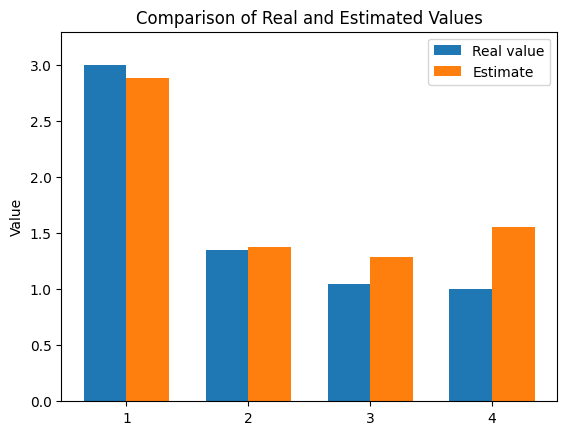

The function param_inverse took 1436.160888 seconds.
| 4         | -0.8373   | 71.62     | 1.031     | 1.318     | 0.2959    |
Sampling 2 chains in parallel


2024-08-23 10:48:20,855	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.703  0.145   2.415    2.912      0.051    0.038       9.0      63.0   
x1  1.024  0.073   0.892    1.152      0.024    0.017       8.0      26.0   
x2  1.467  0.078   1.333    1.597      0.015    0.011      27.0      30.0   
x3  1.689  0.116   1.465    1.902      0.019    0.014      30.0      51.0   

    r_hat  
x0   1.21  
x1   1.18  
x2   1.10  
x3   1.08  
Estimated values are [2.703 1.024 1.467 1.689]
The difference between estimated values [0.297 0.326 0.417 0.689]



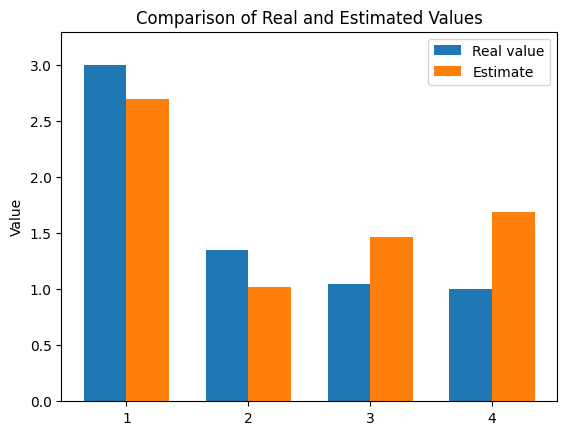

The function param_inverse took 1688.589171 seconds.
| 5         | -1.427    | 64.98     | 3.0       | 5.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-23 11:16:39,645	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.669  0.190   2.391    2.881      0.119    0.097       3.0       3.0   
x1  1.009  0.007   0.992    1.013      0.004    0.003       4.0       3.0   
x2  1.456  0.070   1.408    1.614      0.040    0.032       3.0       2.0   
x3  1.723  0.084   1.634    1.852      0.048    0.038       3.0       2.0   

    r_hat  
x0   2.50  
x1   1.86  
x2   1.86  
x3   2.50  
Estimated values are [2.669 1.009 1.456 1.723]
The difference between estimated values [0.331 0.341 0.406 0.723]



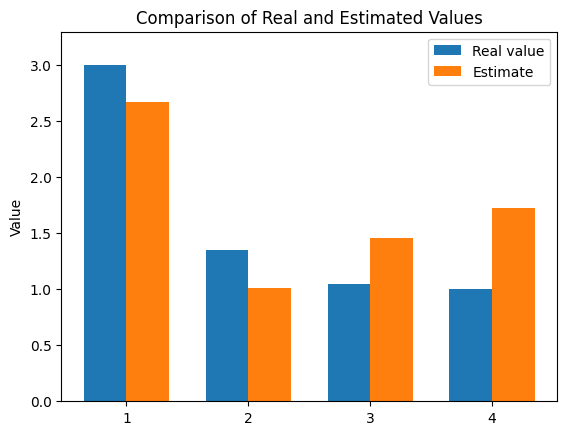

The function param_inverse took 1556.433515 seconds.
| 6         | -1.473    | 76.73     | 2.563     | 2.277     | 0.3646    |
Sampling 2 chains in parallel


2024-08-23 11:40:52,675	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


KeyboardInterrupt: 

In [17]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,80)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( .5,5.)
rwmh_scaling_bounds =  (0.5,3.)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,7.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        subsampling_rate=2,
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model,
                        levels=3, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=15)

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-23 03:27:10,642	INFO worker.py:1788 -- Started a local Ray instance.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.452  0.036   2.376    2.507      0.004    0.003      80.0      30.0   
x1  1.137  0.036   1.062    1.193      0.004    0.003      80.0      30.0   
x2  1.732  0.036   1.657    1.788      0.004    0.003      80.0      30.0   
x3  1.601  0.036   1.525    1.657      0.004    0.003      80.0      30.0   

    r_hat  
x0   1.03  
x1   1.03  
x2   1.03  
x3   1.03  
Estimated values are [2.452 1.137 1.732 1.601]
The difference between estimated values [0.548 0.213 0.682 0.601]



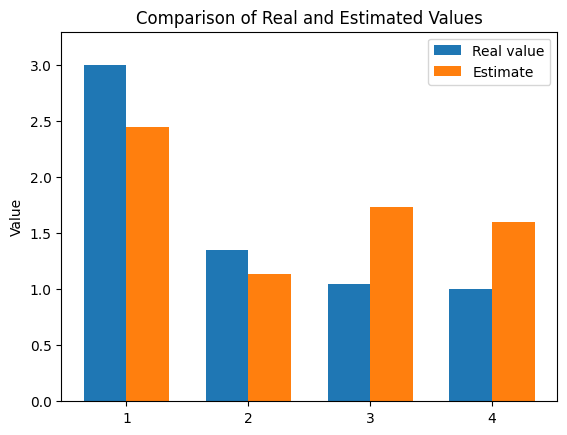

The function param_inverse took 1282.683314 seconds.
| 1         | -1.591    | 48.73     | 2.877     | 3.794     | 0.3997    |
Sampling 2 chains in parallel


2024-08-23 03:49:24,640	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.845  0.002   2.843    2.848      0.001    0.001       3.0       3.0   
x1  1.027  0.002   1.025    1.031      0.001    0.001       3.0       3.0   
x2  1.540  0.002   1.538    1.544      0.001    0.001       3.0       3.0   
x3  1.467  0.002   1.465    1.471      0.001    0.001       3.0       3.0   

    r_hat  
x0   2.25  
x1   2.25  
x2   2.25  
x3   2.25  
Estimated values are [2.845 1.027 1.54  1.467]
The difference between estimated values [0.155 0.323 0.49  0.467]



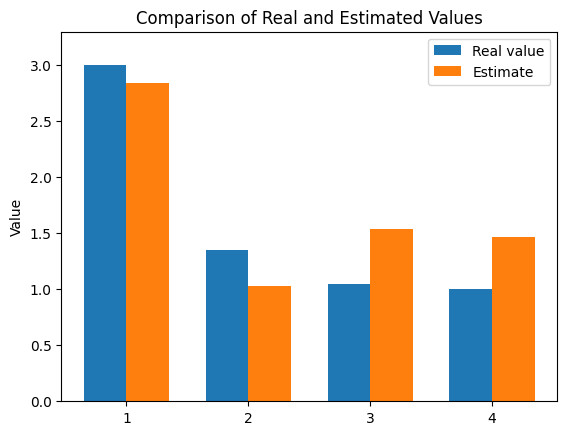

The function param_inverse took 1379.723366 seconds.
| 2         | -1.225    | 37.8      | 0.89      | 0.7614    | 0.4665    |
Sampling 2 chains in parallel


2024-08-23 04:11:32,231	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteMLDAChain pid=1240816) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp
(RemoteMLDAChain pid=1240816)   return np.exp(proposal_link.posterior - previous_link.posterior)


     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  3.009  0.0   3.009    3.010        0.0      0.0       2.0       9.0   3.14
x1  1.048  0.0   1.048    1.048        0.0      0.0       2.0       9.0   3.14
x2  1.334  0.0   1.334    1.334        0.0      0.0       2.0       9.0   3.14
x3  1.575  0.0   1.575    1.576        0.0      0.0       2.0       9.0   3.14
Estimated values are [3.009 1.048 1.334 1.575]
The difference between estimated values [0.009 0.302 0.284 0.575]



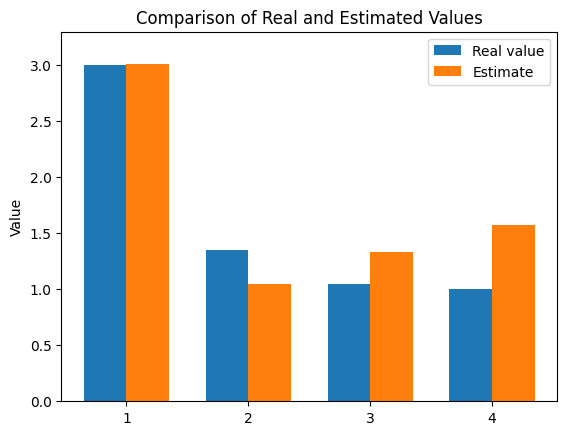

The function param_inverse took 1320.012824 seconds.
| 3         | -1.072    | 60.06     | 2.27      | 0.5926    | 0.4925    |
Sampling 2 chains in parallel


2024-08-23 04:33:44,476	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.395  0.001   2.394    2.395        0.0      0.0       2.0       2.0   
x1  0.976  0.001   0.975    0.977        0.0      0.0       2.0       2.0   
x2  1.669  0.001   1.669    1.670        0.0      0.0       2.0       2.0   
x3  2.157  0.001   2.157    2.158        0.0      0.0       2.0       2.0   

    r_hat  
x0   2.51  
x1   2.51  
x2   2.51  
x3   2.51  
Estimated values are [2.395 0.976 1.669 2.157]
The difference between estimated values [0.605 0.374 0.619 1.157]



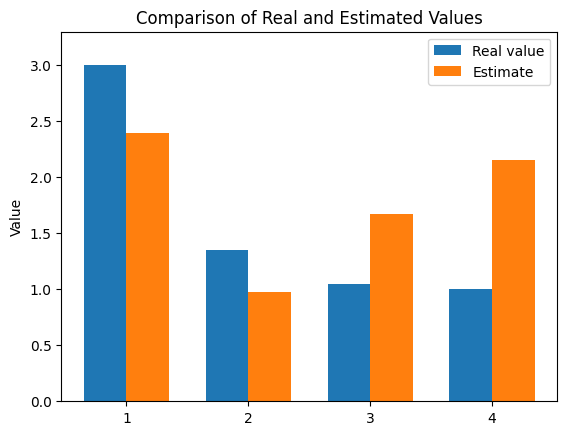

The function param_inverse took 1390.119661 seconds.
| 4         | -2.225    | 71.62     | 1.031     | 1.318     | 0.2959    |
Sampling 2 chains in parallel


2024-08-23 04:56:36,233	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.
(RemoteMLDAChain pid=1267192) c:\Users\Giacomo\miniconda3\Lib\site-packages\tinyDA\proposal.py:236: RuntimeWarning: overflow encountered in exp [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(RemoteMLDAChain pid=1267192)   return np.exp(proposal_link.posterior - previous_link.posterior) [repeated 2x across cluster]


     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
x0  3.098  0.0   3.097    3.098        0.0      0.0       2.0       2.0   4.63
x1  0.824  0.0   0.824    0.824        0.0      0.0       2.0       2.0   4.63
x2  1.692  0.0   1.692    1.693        0.0      0.0       2.0       2.0   4.63
x3  1.515  0.0   1.514    1.515        0.0      0.0       2.0       2.0   4.63
Estimated values are [3.098 0.824 1.692 1.515]
The difference between estimated values [0.098 0.526 0.642 0.515]



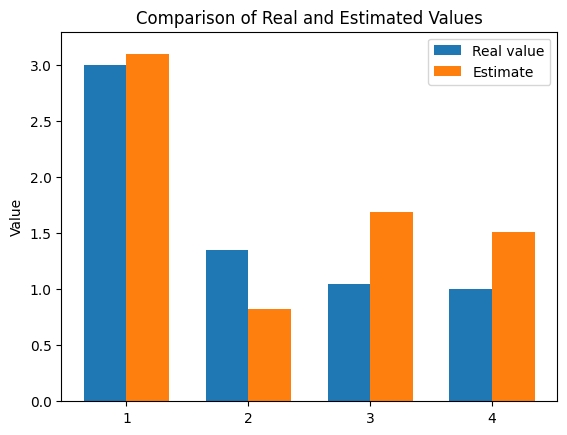

The function param_inverse took 1344.809542 seconds.
| 5         | -1.549    | 60.04     | 2.299     | 0.6518    | 0.4708    |
Sampling 2 chains in parallel


2024-08-23 05:19:16,089	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.690  0.017   2.665    2.718      0.011    0.008       3.0      19.0   
x1  1.125  0.017   1.100    1.154      0.011    0.008       3.0      19.0   
x2  1.686  0.017   1.661    1.714      0.011    0.008       3.0      19.0   
x3  1.584  0.017   1.559    1.613      0.011    0.008       3.0      19.0   

    r_hat  
x0   1.69  
x1   1.69  
x2   1.69  
x3   1.69  
Estimated values are [2.69  1.125 1.686 1.584]
The difference between estimated values [0.31  0.225 0.636 0.584]



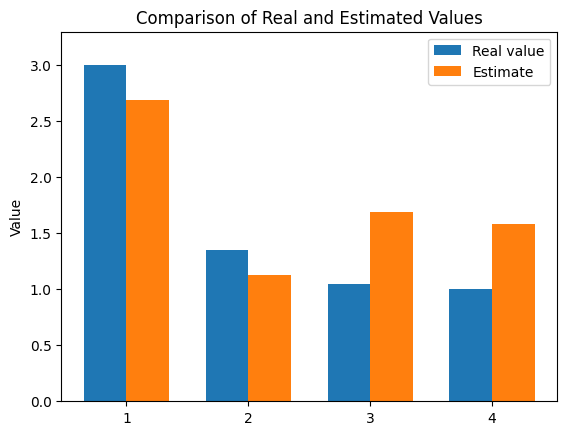

The function param_inverse took 1333.154114 seconds.
| 6         | -1.46     | 76.73     | 2.563     | 2.277     | 0.3646    |
Sampling 2 chains in parallel


2024-08-23 05:41:30,592	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.689  0.019   2.649    2.721      0.004    0.003      24.0      32.0   
x1  1.122  0.019   1.082    1.153      0.004    0.003      24.0      32.0   
x2  1.625  0.019   1.585    1.656      0.004    0.003      24.0      32.0   
x3  1.570  0.019   1.529    1.601      0.004    0.003      24.0      32.0   

    r_hat  
x0   1.19  
x1   1.19  
x2   1.19  
x3   1.19  
Estimated values are [2.689 1.122 1.625 1.57 ]
The difference between estimated values [0.311 0.228 0.575 0.57 ]



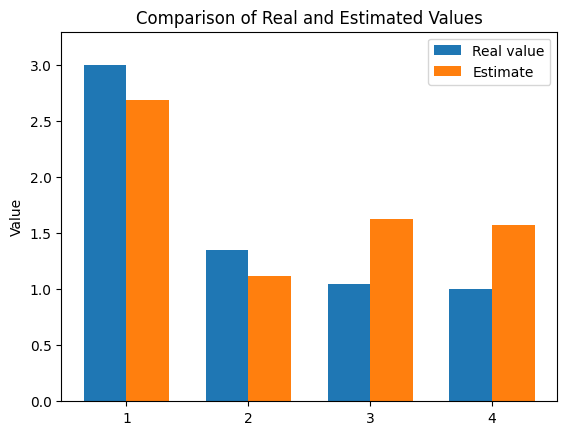

The function param_inverse took 1348.649320 seconds.
| 7         | -1.39     | 78.27     | 1.69      | 3.583     | 0.4893    |
Sampling 2 chains in parallel


2024-08-23 06:04:20,002	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.522  0.048   2.439    2.606      0.003    0.002     222.0     156.0   
x1  1.148  0.048   1.065    1.232      0.003    0.002     222.0     156.0   
x2  1.607  0.048   1.524    1.691      0.003    0.002     222.0     156.0   
x3  1.565  0.048   1.482    1.649      0.003    0.002     222.0     156.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.522 1.148 1.607 1.565]
The difference between estimated values [0.478 0.202 0.557 0.565]



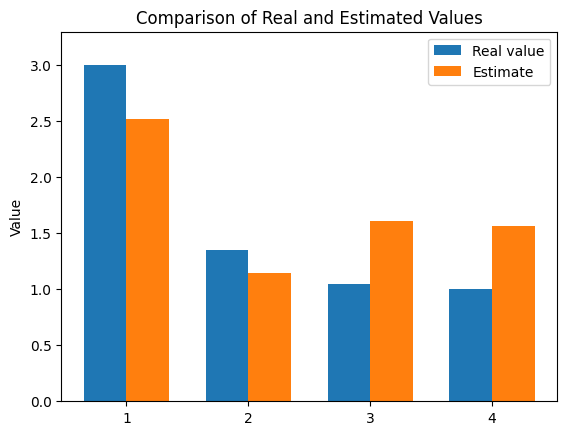

The function param_inverse took 1324.781530 seconds.
| 8         | -1.404    | 56.04     | 1.882     | 4.99      | 0.3336    |
Sampling 2 chains in parallel


2024-08-23 06:26:16,186	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.470  0.019   2.440    2.496       0.01    0.008       4.0      52.0   
x1  1.118  0.019   1.088    1.144       0.01    0.008       4.0      52.0   
x2  1.804  0.019   1.773    1.830       0.01    0.008       4.0      52.0   
x3  1.673  0.019   1.643    1.699       0.01    0.008       4.0      52.0   

    r_hat  
x0   1.46  
x1   1.46  
x2   1.46  
x3   1.46  
Estimated values are [2.47  1.118 1.804 1.673]
The difference between estimated values [0.53  0.232 0.754 0.673]



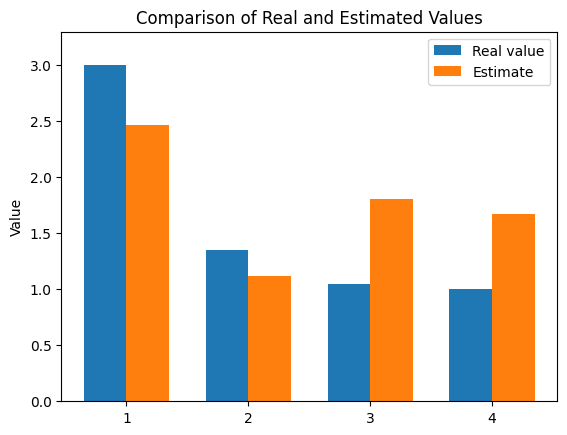

The function param_inverse took 1327.678277 seconds.
| 9         | -1.74     | 58.45     | 1.407     | 2.541     | 0.2565    |
Sampling 2 chains in parallel


2024-08-23 06:48:31,937	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.609  0.012   2.591    2.628      0.008    0.007       2.0      18.0   
x1  1.123  0.012   1.105    1.141      0.008    0.007       2.0      14.0   
x2  1.612  0.012   1.594    1.630      0.008    0.007       2.0      14.0   
x3  1.610  0.012   1.592    1.628      0.008    0.007       2.0      14.0   

    r_hat  
x0   2.89  
x1   2.89  
x2   2.89  
x3   2.89  
Estimated values are [2.609 1.123 1.612 1.61 ]
The difference between estimated values [0.391 0.227 0.562 0.61 ]



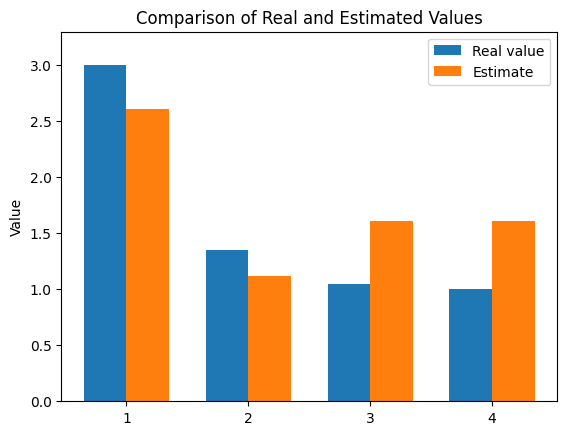

The function param_inverse took 1449.780312 seconds.
| 10        | -1.444    | 76.85     | 2.376     | 1.804     | 0.4675    |
Sampling 2 chains in parallel


2024-08-23 07:12:50,587	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.034  0.024   2.996    3.073      0.016    0.013       2.0      15.0   
x1  0.992  0.024   0.955    1.032      0.016    0.013       2.0      15.0   
x2  1.521  0.024   1.483    1.560      0.016    0.013       2.0      15.0   
x3  1.506  0.024   1.468    1.545      0.016    0.013       2.0      15.0   

    r_hat  
x0   2.71  
x1   2.71  
x2   2.71  
x3   2.71  
Estimated values are [3.034 0.992 1.521 1.506]
The difference between estimated values [0.034 0.358 0.471 0.506]



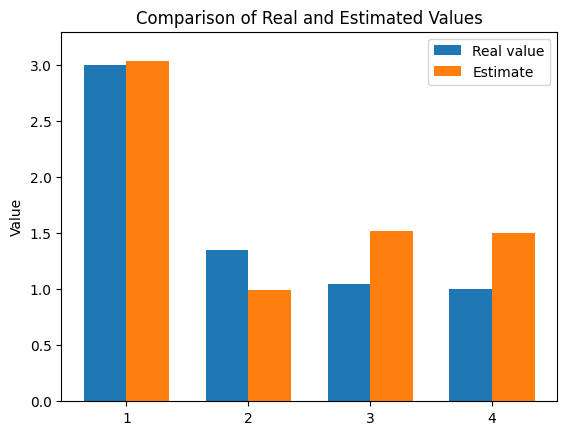

The function param_inverse took 1374.951334 seconds.
| 11        | -1.231    | 42.47     | 2.526     | 2.155     | 0.4766    |
Sampling 2 chains in parallel


2024-08-23 07:35:12,808	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.788  0.032   2.728    2.842      0.006    0.005      21.0      24.0   
x1  1.116  0.032   1.057    1.171      0.006    0.005      21.0      24.0   
x2  1.559  0.032   1.500    1.614      0.006    0.005      21.0      24.0   
x3  1.524  0.032   1.465    1.578      0.006    0.005      21.0      24.0   

    r_hat  
x0   1.11  
x1   1.11  
x2   1.11  
x3   1.11  
Estimated values are [2.788 1.116 1.559 1.524]
The difference between estimated values [0.212 0.234 0.509 0.524]



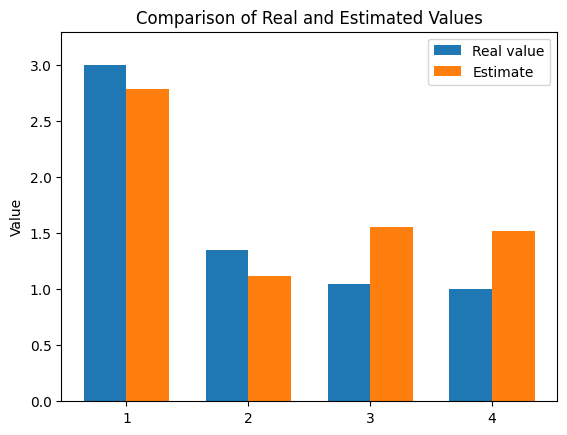

The function param_inverse took 1331.702429 seconds.
| 12        | -1.253    | 36.79     | 0.7199    | 2.894     | 0.2777    |
Sampling 2 chains in parallel


2024-08-23 07:57:31,453	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.764  0.001   2.763    2.765      0.001      0.0       3.0       2.0   
x1  0.960  0.001   0.959    0.961      0.001      0.0       3.0       2.0   
x2  1.551  0.001   1.550    1.552      0.001      0.0       3.0       2.0   
x3  1.708  0.001   1.707    1.709      0.001      0.0       3.0       2.0   

    r_hat  
x0   2.67  
x1   2.67  
x2   2.67  
x3   2.67  
Estimated values are [2.764 0.96  1.551 1.708]
The difference between estimated values [0.236 0.39  0.501 0.708]



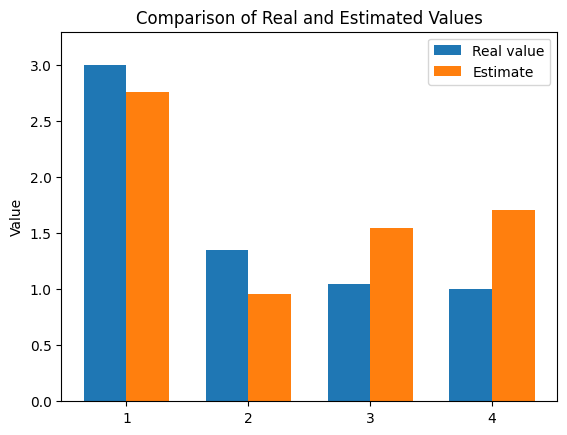

The function param_inverse took 1400.225169 seconds.
| 13        | -1.553    | 76.07     | 0.9851    | 1.159     | 0.3434    |
Sampling 2 chains in parallel


2024-08-23 08:21:12,409	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.768  0.028   2.712    2.819      0.006    0.004      21.0      43.0   
x1  0.986  0.028   0.930    1.038      0.006    0.004      21.0      43.0   
x2  1.544  0.028   1.488    1.596      0.006    0.004      21.0      43.0   
x3  1.603  0.028   1.547    1.655      0.006    0.004      21.0      44.0   

    r_hat  
x0   1.09  
x1   1.09  
x2   1.09  
x3   1.09  
Estimated values are [2.768 0.986 1.544 1.603]
The difference between estimated values [0.232 0.364 0.494 0.603]



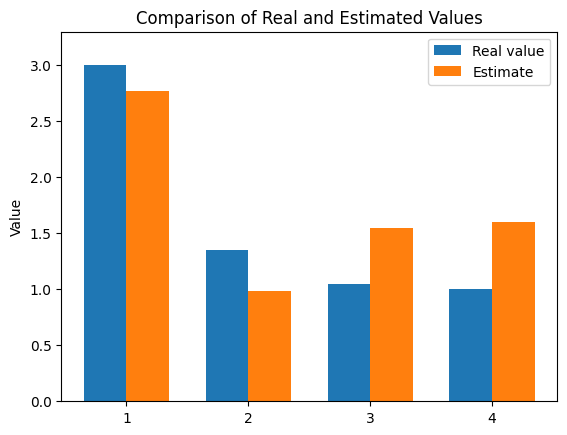

The function param_inverse took 1386.674781 seconds.
| 14        | -1.42     | 50.24     | 0.8901    | 4.142     | 0.2958    |
Sampling 2 chains in parallel


2024-08-23 08:44:16,335	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.549  0.004   2.545    2.556      0.003    0.002       2.0       6.0   
x1  1.293  0.004   1.289    1.301      0.003    0.002       2.0       6.0   
x2  1.698  0.004   1.694    1.706      0.003    0.002       2.0       6.0   
x3  1.522  0.004   1.518    1.529      0.003    0.002       2.0       6.0   

    r_hat  
x0   3.03  
x1   3.03  
x2   3.03  
x3   3.03  
Estimated values are [2.549 1.293 1.698 1.522]
The difference between estimated values [0.451 0.057 0.648 0.522]



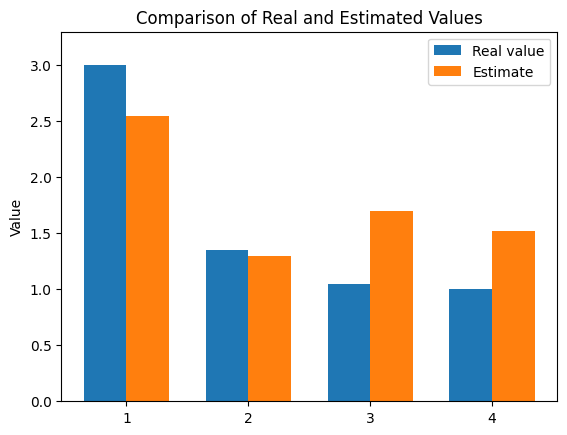

The function param_inverse took 1508.752876 seconds.
| 15        | -1.332    | 79.04     | 1.696     | 1.2       | 0.2902    |


KeyboardInterrupt: 

In [16]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,80)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( .5,5.)
rwmh_scaling_bounds =  (0.5,3.)
rwmh_cov = 1
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

params_MF= HPO_tinyDA(datahf=x_HF, 
                        mean_prior=mean_prior, 
                        cov_prior=cov_prior, 
                        Yhf=y_HF, 
                        sigma_noise=sigma_noise_bounds, 
                        n_data=n_data_bounds,
                        domain=(0.,7.),
                        parameters=parameters, 
                        sigma=sigma_bounds,
                        rwmh_scaling=rwmh_scaling_bounds, 
                        rwmh_cov=rwmh_cov, 
                        rwmh_adaptive=rwmh_adaptive, 
                        iterations=iterations, 
                        subsampling_rate=2,
                        burnin=burnin, 
                        n_chains= n_chains, 
                        final_model=final_model,
                        levels=3, 
                        algo=algo, 
                        force_sequential=False,
                        init_points=4,
                        n_iter=15)

In [ ]:
# Define inputs
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

Yhf = data["Yhf"]
sd_noise = (0.05,0.1)
n_data = (30,50)
parameters =np.array([3.,1.35,1.05,1.])

iterations = 3000
burnin = 2000
number_chains = 2
algo = "NUTS"

proposal_sd = (.5,4.)    # più piccolo, altrimenti scappa da previsione 
scaling = (.5,3.)
adapt = True




module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

#x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

best_estimate, best_error, best_sd_noise, best_proposal_sd, best_n_data, best_scale=HPO_cuqi(
    data= x_HF,
    Yhf=y_HF,
    mean_prior= mean_prior,
    parameters=parameters,
    domain=(0.,7.),
    iterations= iterations,
    burn_in= burnin,
    cov_prior= cov_prior,
    sd_noise=sd_noise,
    proposal_sd= proposal_sd,
    n_data=n_data,
    scale= scaling,
    adapt=adapt,
    number_chains= number_chains,
    algo=algo,
    fwd_model=final_model,
    parallel=False,
    init_points = 4,
    n_iter = 15
) 

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-21 02:38:33,187	INFO worker.py:1788 -- Started a local Ray instance.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.179  0.054   2.094    2.269      0.004    0.003     269.0     301.0   
x1  0.679  0.054   0.594    0.769      0.004    0.003     269.0     301.0   
x2  1.179  0.054   1.094    1.269      0.004    0.003     269.0     301.0   
x3  1.179  0.054   1.094    1.269      0.004    0.003     269.0     301.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.179 0.679 1.179 1.179]
The difference between estimated values [0.821 0.671 0.129 0.179]



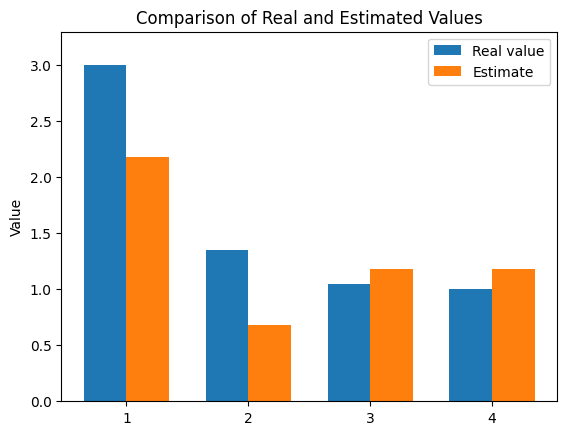

The function param_inverse took 529.586222 seconds.
| 1         | -0.2681   | 41.24     | 1.926     | 3.464     | 0.3997    |
Sampling 2 chains in parallel


2024-08-21 02:47:55,212	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.101  0.025   2.061    2.156      0.001    0.001     329.0     302.0   
x1  0.622  0.025   0.581    0.676      0.001    0.001     329.0     302.0   
x2  1.161  0.025   1.120    1.215      0.001    0.001     329.0     302.0   
x3  1.048  0.025   1.007    1.102      0.001    0.001     329.0     302.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.101 0.622 1.161 1.048]
The difference between estimated values [0.899 0.728 0.111 0.048]



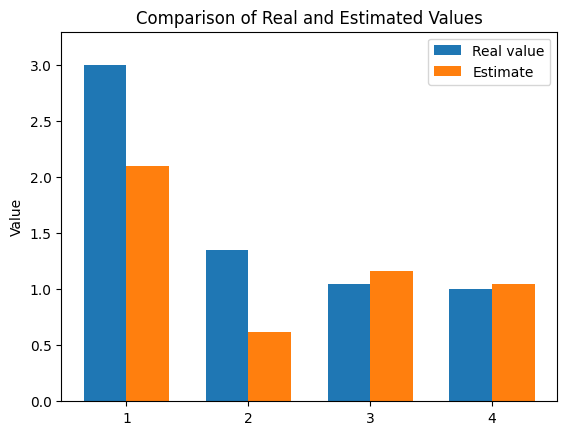

The function param_inverse took 550.738510 seconds.
| 2         | -0.2482   | 34.68     | 0.734     | 2.116     | 0.4665    |
Sampling 2 chains in parallel


2024-08-21 02:57:23,381	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.856  0.019   1.822    1.891      0.001    0.001     209.0     316.0   
x1  0.864  0.019   0.830    0.899      0.001    0.001     209.0     316.0   
x2  1.108  0.019   1.073    1.143      0.001    0.001     209.0     316.0   
x3  1.258  0.019   1.224    1.293      0.001    0.001     209.0     316.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [1.856 0.864 1.108 1.258]
The difference between estimated values [1.144 0.486 0.058 0.258]



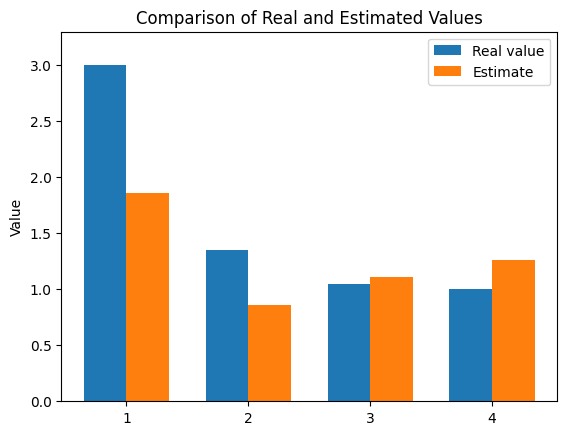

The function param_inverse took 565.275050 seconds.
| 3         | -0.2636   | 48.03     | 1.562     | 2.041     | 0.4925    |
Sampling 2 chains in parallel


2024-08-21 03:06:48,903	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.031  0.022   1.986    2.066      0.001    0.001     475.0     282.0   
x1  0.486  0.022   0.442    0.522      0.001    0.001     475.0     282.0   
x2  0.806  0.022   0.762    0.842      0.001    0.001     475.0     282.0   
x3  1.369  0.022   1.325    1.405      0.001    0.001     475.0     282.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.031 0.486 0.806 1.369]
The difference between estimated values [0.969 0.864 0.244 0.369]



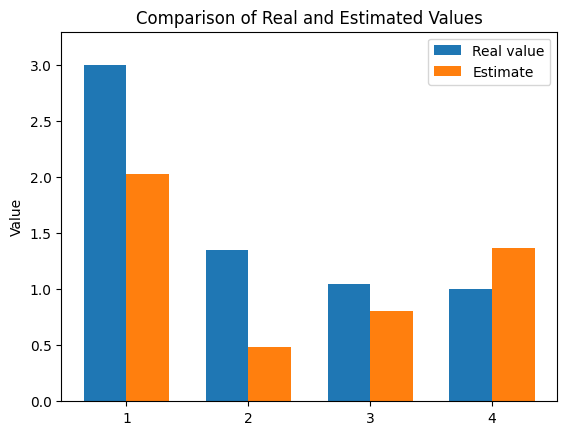

The function param_inverse took 565.976542 seconds.
| 4         | -0.3911   | 54.97     | 0.8185    | 2.364     | 0.2959    |
Sampling 2 chains in parallel


2024-08-21 03:16:04,156	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.181  0.032   2.122    2.234      0.002    0.001     303.0     211.0   
x1  0.756  0.032   0.696    0.809      0.002    0.001     303.0     211.0   
x2  1.157  0.032   1.098    1.210      0.002    0.001     303.0     211.0   
x3  0.991  0.032   0.932    1.044      0.002    0.001     303.0     211.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.181 0.756 1.157 0.991]
The difference between estimated values [0.819 0.594 0.107 0.009]



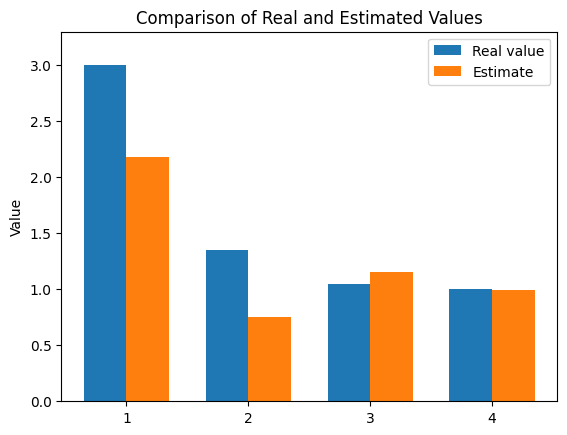

The function param_inverse took 553.935682 seconds.
| 5         | -0.206    | 39.13     | 1.287     | 2.864     | 0.3228    |
Sampling 2 chains in parallel


2024-08-21 03:25:07,377	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.310  0.07   2.195    2.451      0.004    0.003     279.0     342.0   
x1  0.920  0.07   0.804    1.061      0.004    0.003     279.0     342.0   
x2  1.232  0.07   1.116    1.373      0.004    0.003     279.0     342.0   
x3  1.128  0.07   1.013    1.269      0.004    0.003     279.0     342.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.31  0.92  1.232 1.128]
The difference between estimated values [0.69  0.43  0.182 0.128]



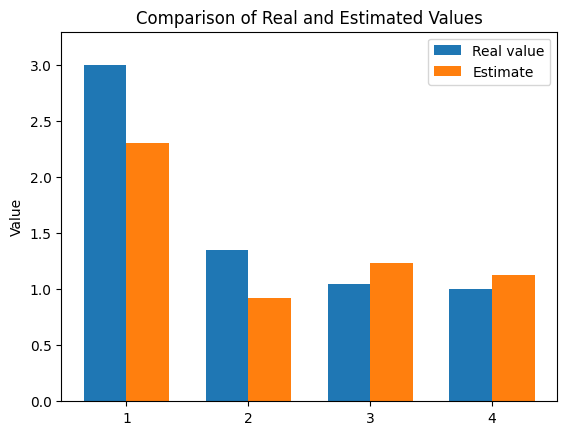

The function param_inverse took 543.269447 seconds.
| 6         | -0.2125   | 37.05     | 2.0       | 4.0       | 0.5       |
Sampling 2 chains in parallel


2024-08-21 03:34:13,699	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.082  0.077   1.955    2.233      0.005    0.004     211.0     243.0   
x1  0.863  0.077   0.735    1.014      0.005    0.004     211.0     243.0   
x2  1.360  0.077   1.233    1.512      0.005    0.004     211.0     243.0   
x3  1.436  0.077   1.308    1.587      0.005    0.004     211.0     243.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.082 0.863 1.36  1.436]
The difference between estimated values [0.918 0.487 0.31  0.436]



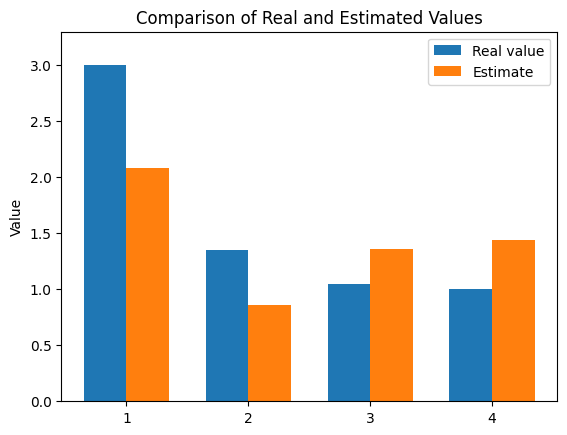

The function param_inverse took 521.342321 seconds.
| 7         | -0.3495   | 30.0      | 2.0       | 4.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-21 03:42:47,465	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.526  0.032   3.462    3.587      0.002    0.001     271.0     298.0   
x1  1.258  0.032   1.194    1.319      0.002    0.001     271.0     298.0   
x2  1.733  0.032   1.669    1.794      0.002    0.001     271.0     298.0   
x3  2.059  0.032   1.995    2.120      0.002    0.001     271.0     298.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [3.526 1.258 1.733 2.059]
The difference between estimated values [0.526 0.092 0.683 1.059]



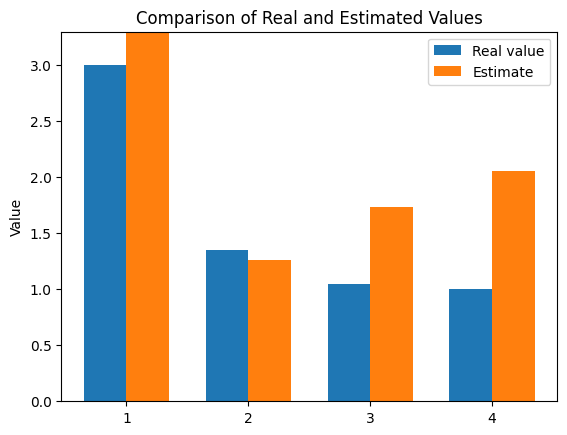

The function param_inverse took 541.165316 seconds.
| 8         | -0.4882   | 37.44     | 2.0       | 2.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-21 03:51:57,195	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.240  0.058   2.151    2.354      0.004    0.003     270.0     246.0   
x1  0.848  0.058   0.758    0.961      0.004    0.003     270.0     246.0   
x2  1.154  0.058   1.064    1.267      0.004    0.003     270.0     246.0   
x3  1.102  0.058   1.012    1.215      0.004    0.003     270.0     246.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.24  0.848 1.154 1.102]
The difference between estimated values [0.76  0.502 0.104 0.102]



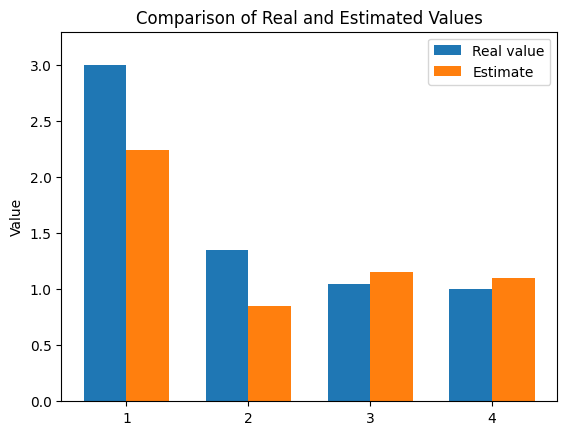

The function param_inverse took 577.084228 seconds.
| 9         | -0.2066   | 45.62     | 1.329     | 3.995     | 0.3336    |
Sampling 2 chains in parallel


2024-08-21 04:01:35,618	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.133  0.029   2.081    2.190      0.002    0.001     318.0     292.0   
x1  0.628  0.029   0.576    0.685      0.002    0.001     318.0     292.0   
x2  1.144  0.029   1.093    1.201      0.002    0.001     318.0     292.0   
x3  1.092  0.029   1.040    1.148      0.002    0.001     318.0     292.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.133 0.628 1.144 1.092]
The difference between estimated values [0.867 0.722 0.094 0.092]



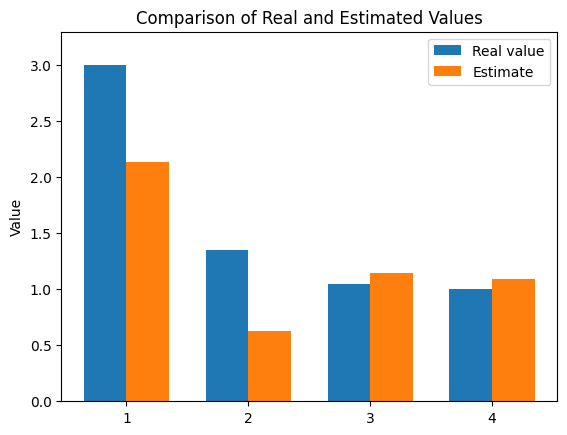

The function param_inverse took 564.115244 seconds.
| 10        | -0.2513   | 47.07     | 1.044     | 2.907     | 0.2565    |
Sampling 2 chains in parallel


2024-08-21 04:11:10,889	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.158  0.04    2.08    2.226      0.003    0.002     249.0     301.0   
x1  0.658  0.04    0.58    0.726      0.003    0.002     249.0     301.0   
x2  1.158  0.04    1.08    1.226      0.003    0.002     249.0     301.0   
x3  1.158  0.04    1.08    1.226      0.003    0.002     249.0     301.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.158 0.658 1.158 1.158]
The difference between estimated values [0.842 0.692 0.108 0.158]



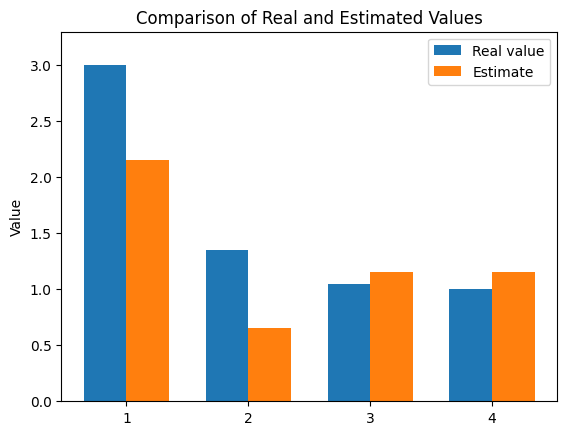

The function param_inverse took 567.763548 seconds.
| 11        | -0.2635   | 39.5      | 1.226     | 3.086     | 0.4023    |
Sampling 2 chains in parallel


2024-08-21 04:20:57,401	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.412  0.053   2.300    2.503      0.003    0.002     382.0     226.0   
x1  0.897  0.053   0.785    0.988      0.003    0.002     382.0     226.0   
x2  1.419  0.053   1.307    1.510      0.003    0.002     382.0     226.0   
x3  0.617  0.053   0.504    0.708      0.003    0.002     382.0     226.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.412 0.897 1.419 0.617]
The difference between estimated values [0.588 0.453 0.369 0.383]



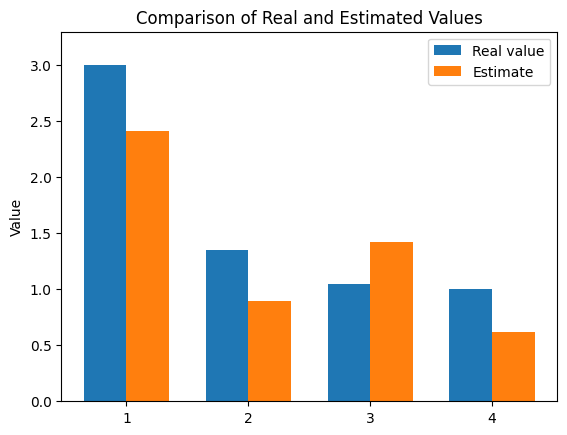

The function param_inverse took 581.129859 seconds.
| 12        | -0.3165   | 39.11     | 1.281     | 2.855     | 0.3435    |
Sampling 2 chains in parallel


2024-08-21 04:30:17,601	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.134  0.064   2.040    2.284      0.003    0.002     376.0     319.0   
x1  0.869  0.064   0.775    1.019      0.003    0.002     376.0     319.0   
x2  1.091  0.064   0.997    1.241      0.003    0.002     376.0     319.0   
x3  1.315  0.064   1.220    1.465      0.003    0.002     376.0     319.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.134 0.869 1.091 1.315]
The difference between estimated values [0.866 0.481 0.041 0.315]



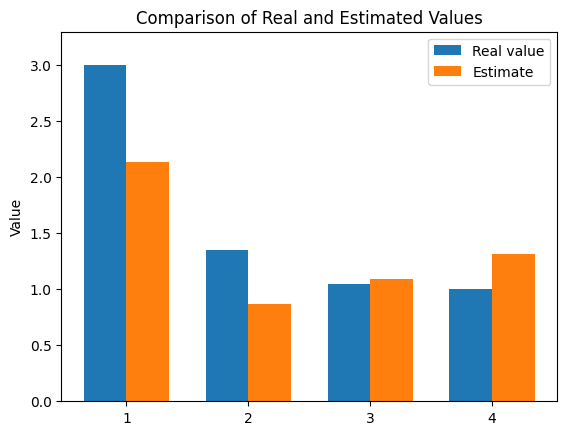

The function param_inverse took 560.296774 seconds.
| 13        | -0.2498   | 34.07     | 0.632     | 3.064     | 0.2777    |
Sampling 2 chains in parallel


2024-08-21 04:39:42,679	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.087  0.023   2.046    2.130      0.001    0.001     332.0     270.0   
x1  0.603  0.023   0.562    0.646      0.001    0.001     332.0     270.0   
x2  1.218  0.023   1.177    1.260      0.001    0.001     332.0     270.0   
x3  1.006  0.023   0.965    1.049      0.001    0.001     332.0     270.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.087 0.603 1.218 1.006]
The difference between estimated values [0.913 0.747 0.168 0.006]



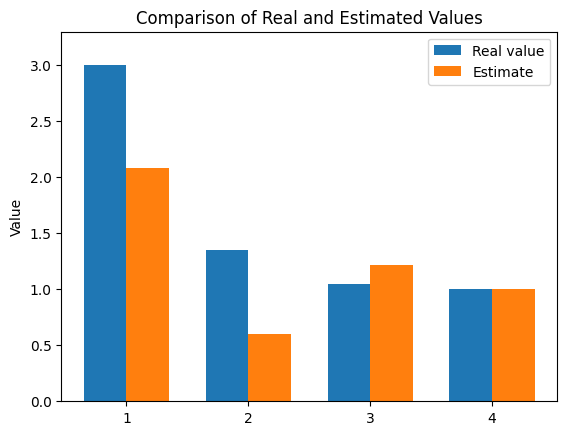

The function param_inverse took 565.925806 seconds.
| 14        | -0.2559   | 57.64     | 0.791     | 2.293     | 0.3434    |
Sampling 2 chains in parallel


2024-08-21 04:48:56,076	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.906  0.05   2.826    3.019      0.003    0.002     361.0     197.0   
x1  0.898  0.05   0.817    1.010      0.003    0.002     361.0     197.0   
x2  1.215  0.05   1.135    1.328      0.003    0.002     361.0     207.0   
x3  0.633  0.05   0.552    0.745      0.003    0.002     361.0     197.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.906 0.898 1.215 0.633]
The difference between estimated values [0.094 0.452 0.165 0.367]



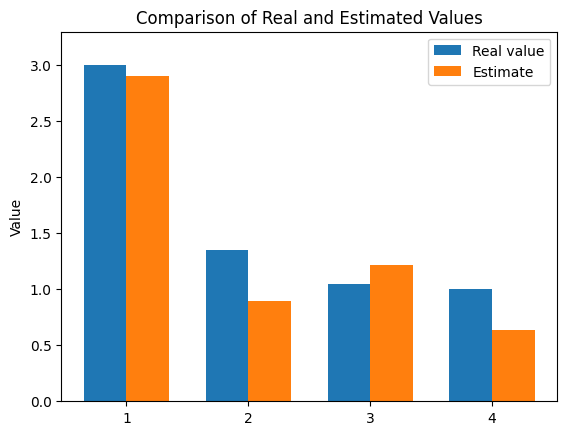

The function param_inverse took 555.671012 seconds.
| 15        | -0.2226   | 42.14     | 0.734     | 3.619     | 0.2958    |
Sampling 2 chains in parallel


2024-08-21 04:58:20,099	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.104  0.024   2.063    2.149      0.001    0.001     355.0     286.0   
x1  0.752  0.024   0.711    0.797      0.001    0.001     355.0     286.0   
x2  1.239  0.024   1.197    1.283      0.001    0.001     355.0     286.0   
x3  0.894  0.024   0.853    0.939      0.001    0.001     355.0     286.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.104 0.752 1.239 0.894]
The difference between estimated values [0.896 0.598 0.189 0.106]



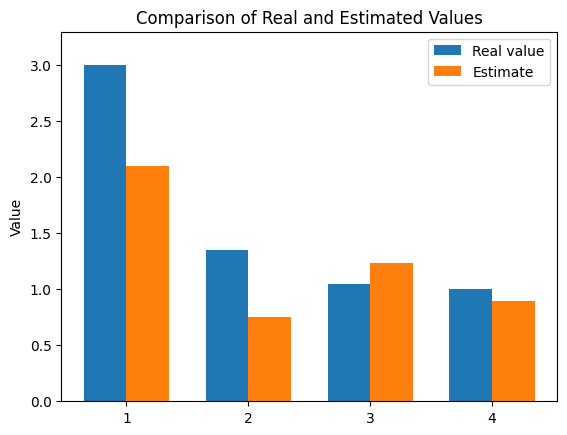

The function param_inverse took 563.513142 seconds.
| 16        | -0.2569   | 59.42     | 1.218     | 2.311     | 0.2902    |
Sampling 2 chains in parallel


2024-08-21 05:08:01,798	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.109  0.024   2.066    2.151      0.001    0.001     319.0     454.0   
x1  0.609  0.024   0.566    0.651      0.001    0.001     319.0     454.0   
x2  1.109  0.024   1.066    1.151      0.001    0.001     319.0     454.0   
x3  1.109  0.024   1.066    1.151      0.001    0.001     319.0     454.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.109 0.609 1.109 1.109]
The difference between estimated values [0.891 0.741 0.059 0.109]



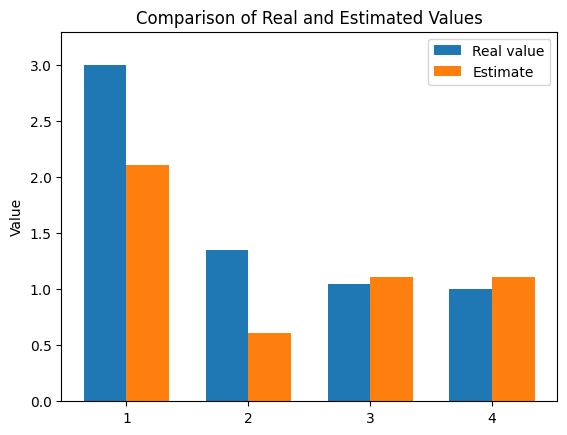

The function param_inverse took 581.865337 seconds.
| 17        | -0.2528   | 56.24     | 0.8244    | 2.787     | 0.416     |
Sampling 2 chains in parallel


2024-08-21 05:17:19,306	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.769  0.024   1.722    1.816      0.001    0.001     410.0     319.0   
x1  0.835  0.024   0.788    0.882      0.001    0.001     410.0     319.0   
x2  1.337  0.024   1.290    1.384      0.001    0.001     410.0     319.0   
x3  1.263  0.024   1.216    1.310      0.001    0.001     410.0     319.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [1.769 0.835 1.337 1.263]
The difference between estimated values [1.231 0.515 0.287 0.263]



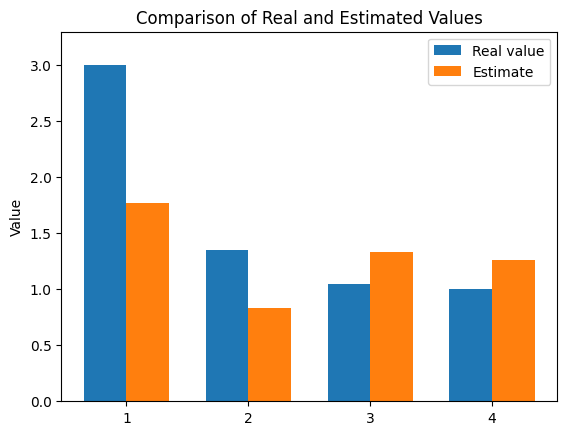

The function param_inverse took 555.353065 seconds.
| 18        | -0.332    | 33.91     | 1.306     | 2.054     | 0.2545    |
Sampling 2 chains in parallel


2024-08-21 05:26:33,366	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.293  0.102   2.127    2.482      0.006    0.004     290.0     329.0   
x1  0.779  0.102   0.613    0.968      0.006    0.004     290.0     329.0   
x2  1.304  0.102   1.138    1.493      0.006    0.004     290.0     329.0   
x3  1.253  0.102   1.087    1.442      0.006    0.004     290.0     329.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.293 0.779 1.304 1.253]
The difference between estimated values [0.707 0.571 0.254 0.253]



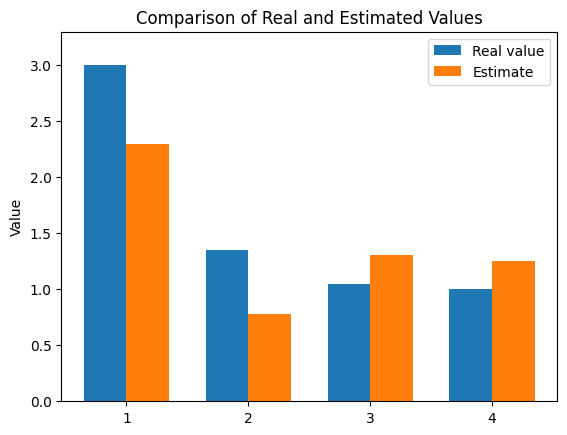

The function param_inverse took 494.864513 seconds.
| 19        | -0.2884   | 32.97     | 1.715     | 3.608     | 0.4938    |
Sampling 2 chains in parallel


2024-08-21 05:34:53,977	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.227  0.048   2.143    2.328      0.003    0.002     303.0     252.0   
x1  0.972  0.048   0.888    1.074      0.003    0.002     303.0     252.0   
x2  1.429  0.048   1.345    1.531      0.003    0.002     303.0     252.0   
x3  0.710  0.048   0.626    0.812      0.003    0.002     303.0     252.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.227 0.972 1.429 0.71 ]
The difference between estimated values [0.773 0.378 0.379 0.29 ]



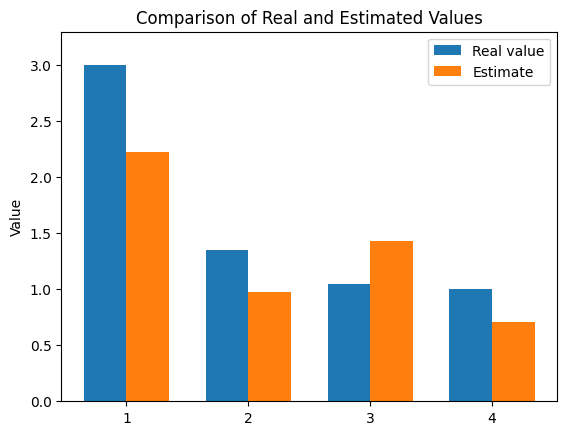

The function param_inverse took 560.753655 seconds.
| 20        | -0.2972   | 55.72     | 1.365     | 3.844     | 0.311     |
Sampling 2 chains in parallel


2024-08-21 05:44:30,929	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.328  0.021   2.293    2.369      0.001    0.001     294.0     225.0   
x1  0.489  0.021   0.454    0.529      0.001    0.001     294.0     225.0   
x2  1.009  0.021   0.974    1.050      0.001    0.001     294.0     225.0   
x3  0.925  0.021   0.890    0.966      0.001    0.001     294.0     225.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.328 0.489 1.009 0.925]
The difference between estimated values [0.672 0.861 0.041 0.075]



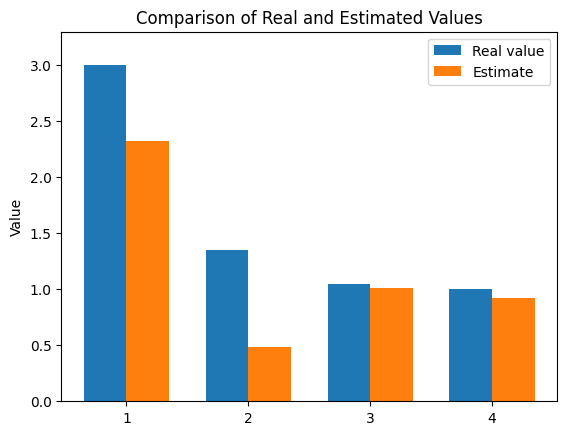

The function param_inverse took 578.432489 seconds.
| 21        | -0.244    | 55.0      | 1.145     | 2.496     | 0.314     |
Sampling 2 chains in parallel


2024-08-21 05:54:05,650	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.117  0.022   2.079    2.163      0.001    0.001     356.0     493.0   
x1  0.701  0.022   0.663    0.746      0.001    0.001     356.0     493.0   
x2  1.071  0.022   1.033    1.117      0.001    0.001     356.0     493.0   
x3  1.083  0.022   1.045    1.128      0.001    0.001     356.0     493.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [2.117 0.701 1.071 1.083]
The difference between estimated values [0.883 0.649 0.021 0.083]



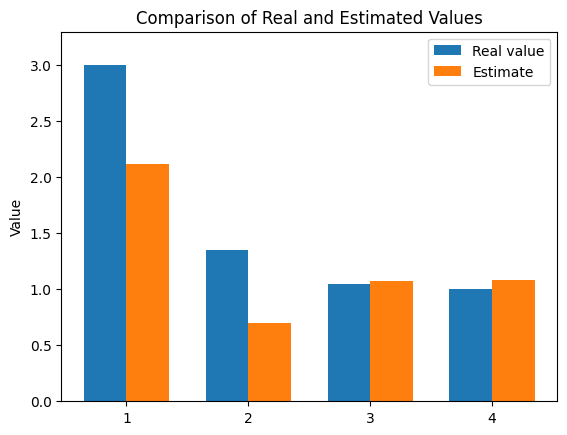

The function param_inverse took 578.740297 seconds.
| 22        | -0.2195   | 52.93     | 1.15      | 2.671     | 0.3851    |
Sampling 2 chains in parallel


2024-08-21 06:03:26,390	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.154  0.026   2.106    2.199      0.002    0.001     296.0     257.0   
x1  0.582  0.026   0.533    0.627      0.002    0.001     296.0     257.0   
x2  0.952  0.026   0.903    0.997      0.002    0.001     296.0     257.0   
x3  1.172  0.026   1.123    1.217      0.002    0.001     296.0     257.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.154 0.582 0.952 1.172]
The difference between estimated values [0.846 0.768 0.098 0.172]



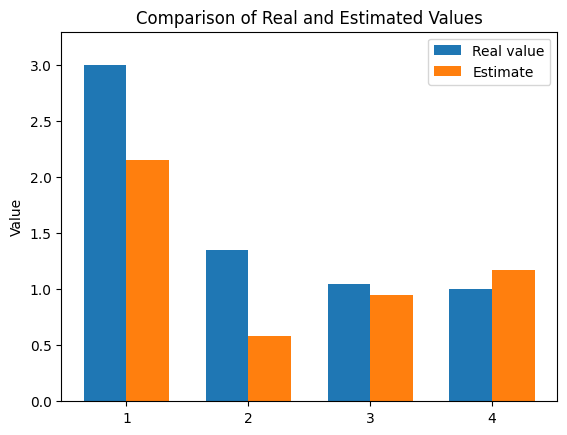

The function param_inverse took 558.382383 seconds.
| 23        | -0.2791   | 57.1      | 1.538     | 2.938     | 0.2803    |
Sampling 2 chains in parallel


2024-08-21 06:13:00,718	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.252  0.072   2.107    2.366      0.004    0.003     326.0     243.0   
x1  0.877  0.072   0.733    0.992      0.004    0.003     326.0     243.0   
x2  1.692  0.072   1.548    1.807      0.004    0.003     326.0     243.0   
x3  0.484  0.072   0.339    0.598      0.004    0.003     326.0     243.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.252 0.877 1.692 0.484]
The difference between estimated values [0.748 0.473 0.642 0.516]



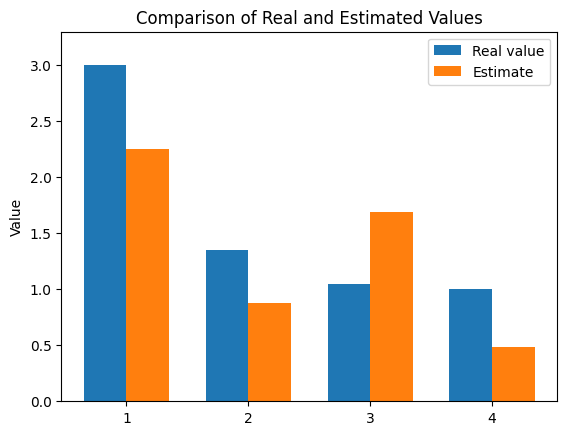

The function param_inverse took 577.908310 seconds.
| 24        | -0.4318   | 44.05     | 1.208     | 3.922     | 0.4252    |
Sampling 2 chains in parallel


2024-08-21 06:22:43,992	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.022  0.048   1.940    2.111      0.003    0.002     307.0     300.0   
x1  0.832  0.048   0.749    0.920      0.003    0.002     307.0     300.0   
x2  1.235  0.048   1.152    1.323      0.003    0.002     307.0     300.0   
x3  1.260  0.048   1.177    1.348      0.003    0.002     307.0     300.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.022 0.832 1.235 1.26 ]
The difference between estimated values [0.978 0.518 0.185 0.26 ]



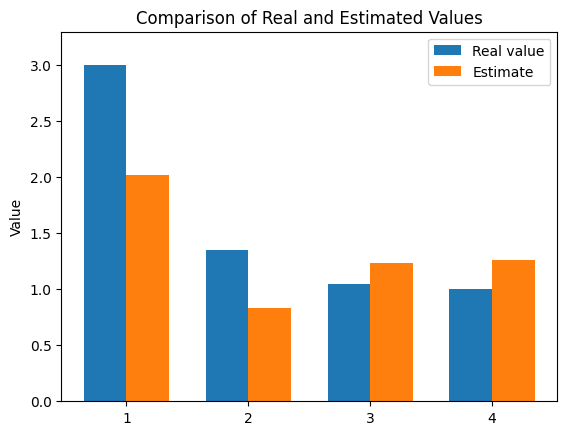

The function param_inverse took 582.033350 seconds.
| 25        | -0.2865   | 47.34     | 0.7909    | 3.993     | 0.4158    |
Sampling 2 chains in parallel


2024-08-21 06:32:12,087	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.465  0.083   2.322    2.623      0.005    0.003     316.0     388.0   
x1  0.945  0.083   0.802    1.102      0.005    0.003     316.0     388.0   
x2  1.425  0.083   1.282    1.583      0.005    0.003     316.0     388.0   
x3  1.764  0.083   1.621    1.921      0.005    0.003     316.0     388.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.465 0.945 1.425 1.764]
The difference between estimated values [0.535 0.405 0.375 0.764]



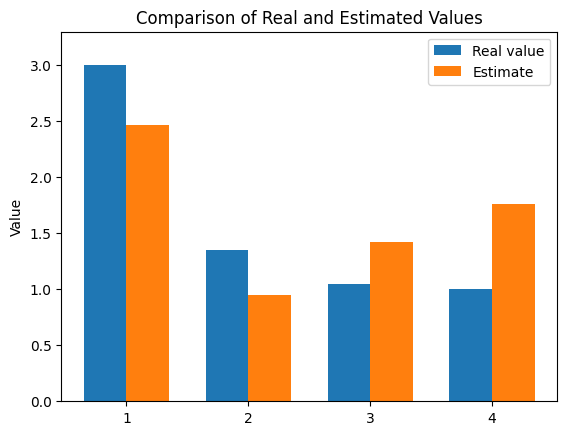

The function param_inverse took 560.448482 seconds.
| 26        | -0.3999   | 30.74     | 1.218     | 3.513     | 0.3815    |
Sampling 2 chains in parallel


2024-08-21 06:41:43,781	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.141  0.04   2.055    2.207      0.002    0.001     384.0     287.0   
x1  0.810  0.04   0.725    0.876      0.002    0.001     384.0     287.0   
x2  1.356  0.04   1.271    1.422      0.002    0.001     384.0     287.0   
x3  0.927  0.04   0.842    0.993      0.002    0.001     384.0     287.0   

    r_hat  
x0    1.0  
x1    1.0  
x2    1.0  
x3    1.0  
Estimated values are [2.141 0.81  1.356 0.927]
The difference between estimated values [0.859 0.54  0.306 0.073]



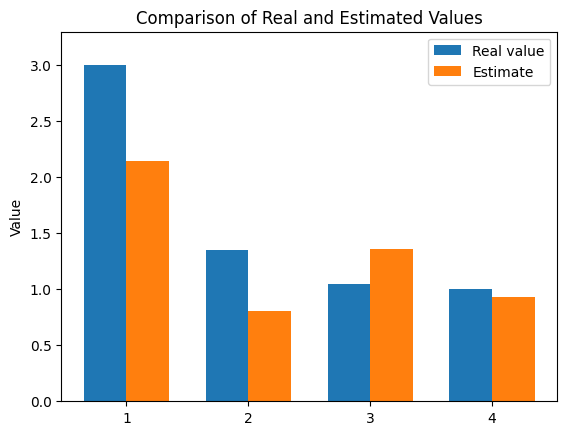

The function param_inverse took 599.106077 seconds.
| 27        | -0.2627   | 53.31     | 0.6108    | 3.672     | 0.2548    |
Sampling 2 chains in parallel


2024-08-21 06:51:58,497	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.799  0.068   1.688    1.916      0.005    0.003     217.0     233.0   
x1  0.806  0.068   0.696    0.924      0.005    0.003     217.0     233.0   
x2  1.353  0.068   1.242    1.471      0.005    0.003     217.0     233.0   
x3  1.684  0.068   1.573    1.801      0.005    0.003     217.0     233.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [1.799 0.806 1.353 1.684]
The difference between estimated values [1.201 0.544 0.303 0.684]



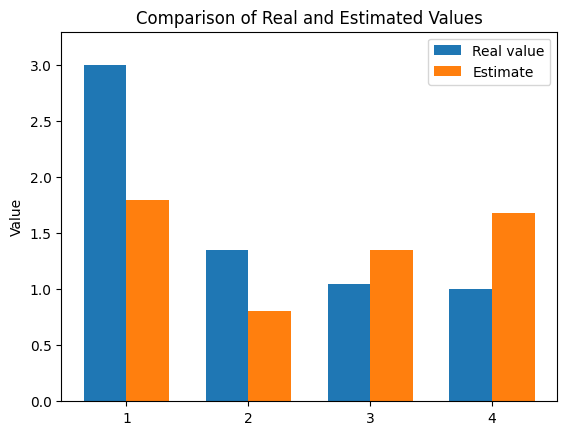

The function param_inverse took 597.829244 seconds.
| 28        | -0.444    | 33.81     | 0.8165    | 3.257     | 0.493     |
Sampling 2 chains in parallel


2024-08-21 07:01:33,701	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.087  0.018   2.050    2.117      0.001    0.001     311.0     292.0   
x1  0.566  0.018   0.529    0.596      0.001    0.001     311.0     292.0   
x2  1.059  0.018   1.021    1.088      0.001    0.001     311.0     292.0   
x3  1.132  0.018   1.095    1.162      0.001    0.001     311.0     292.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.087 0.566 1.059 1.132]
The difference between estimated values [0.913 0.784 0.009 0.132]



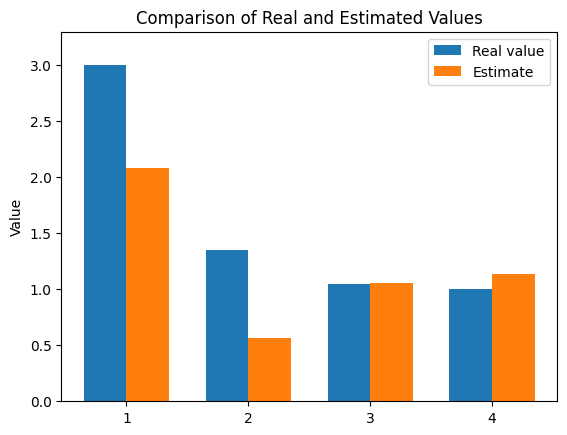

The function param_inverse took 584.528941 seconds.
| 29        | -0.2564   | 53.72     | 1.352     | 2.233     | 0.4101    |
Sampling 2 chains in parallel


2024-08-21 07:11:36,189	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.103  0.025   2.062    2.154      0.001    0.001     282.0     354.0   
x1  0.613  0.025   0.571    0.664      0.001    0.001     282.0     354.0   
x2  1.137  0.025   1.096    1.189      0.001    0.001     282.0     354.0   
x3  1.103  0.025   1.062    1.154      0.001    0.001     282.0     354.0   

    r_hat  
x0   1.01  
x1   1.01  
x2   1.01  
x3   1.01  
Estimated values are [2.103 0.613 1.137 1.103]
The difference between estimated values [0.897 0.737 0.087 0.103]



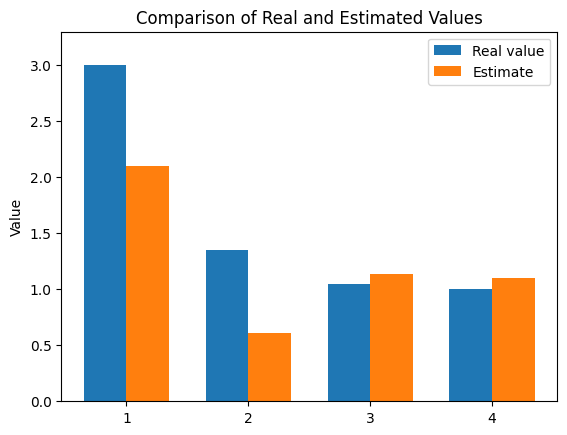

The function param_inverse took 601.484271 seconds.
| 30        | -0.2577   | 37.17     | 1.988     | 2.248     | 0.3292    |


In [19]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,60)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( 2.,4.)
rwmh_scaling_bounds =  (0.5,2.)
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF= HPO_tinyDA(datahf=datatest, 
                                                    mean_prior=mean_prior, 
                                                    cov_prior=cov_prior, 
                                                    domain=(0.,7.),
                                                    Yhf=np.array(y_test).reshape(-1,2), 
                                                    sigma_noise_bounds=sigma_noise_bounds, 
                                                    n_data_bounds=n_data_bounds,
                                                    parameters=parameters, 
                                                    sigma_bounds=sigma_bounds,
                                                    rwmh_scaling_bounds=rwmh_scaling_bounds, 
                                                    rwmh_cov=rwmh_cov, 
                                                    rwmh_adaptive=rwmh_adaptive, 
                                                    iterations=iterations, 
                                                    burnin=burnin, 
                                                    n_chains= n_chains, 
                                                    final_model=final_model,
                                                    levels=1, 
                                                    algo=algo, 
                                                    force_sequential=False)

In [ ]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,60)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( 2.,4.)
rwmh_scaling_bounds =  (0.5,2.)
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "AM"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF= HPO_tinyDA(datahf=datatest, 
                                                    mean_prior=mean_prior, 
                                                    cov_prior=cov_prior, 
                                                    domain=(0.,7.),
                                                    Yhf=np.array(y_test).reshape(-1,2), 
                                                    sigma_noise_bounds=sigma_noise_bounds, 
                                                    n_data_bounds=n_data_bounds,
                                                    parameters=parameters, 
                                                    sigma_bounds=sigma_bounds,
                                                    rwmh_scaling_bounds=rwmh_scaling_bounds, 
                                                    rwmh_cov=rwmh_cov, 
                                                    rwmh_adaptive=rwmh_adaptive, 
                                                    iterations=iterations, 
                                                    burnin=burnin, 
                                                    n_chains= n_chains, 
                                                    final_model=final_model,
                                                    levels=1, 
                                                    algo=algo, 
                                                    force_sequential=False)

|   iter    |  target   |  n_data   | rwmh_s... |   sigma   | sigma_... |
-------------------------------------------------------------------------
Sampling 2 chains in parallel


2024-08-21 07:21:28,911	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.850  0.148   1.585    2.115      0.013    0.009     128.0     161.0   
x1  0.908  0.094   0.699    1.040      0.009    0.006     116.0     171.0   
x2  1.412  0.103   1.206    1.585      0.009    0.007     126.0     146.0   
x3  1.163  0.172   0.805    1.456      0.016    0.012     113.0     164.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.01  
x3   1.03  
Estimated values are [1.85  0.908 1.412 1.163]
The difference between estimated values [1.15  0.442 0.362 0.163]



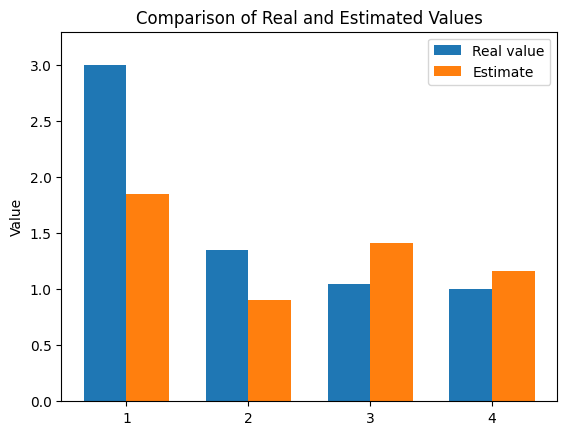

The function param_inverse took 593.098317 seconds.
| 1         | -0.3046   | 41.24     | 1.926     | 3.464     | 0.3997    |
Sampling 2 chains in parallel


2024-08-21 07:31:18,777	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.845  0.096   1.693    2.037      0.012    0.008      68.0     179.0   
x1  0.833  0.068   0.729    0.954      0.007    0.005      95.0     178.0   
x2  1.337  0.077   1.191    1.468      0.008    0.006      94.0     114.0   
x3  1.163  0.112   0.920    1.328      0.017    0.012      47.0      97.0   

    r_hat  
x0   1.06  
x1   1.04  
x2   1.05  
x3   1.06  
Estimated values are [1.845 0.833 1.337 1.163]
The difference between estimated values [1.155 0.517 0.287 0.163]



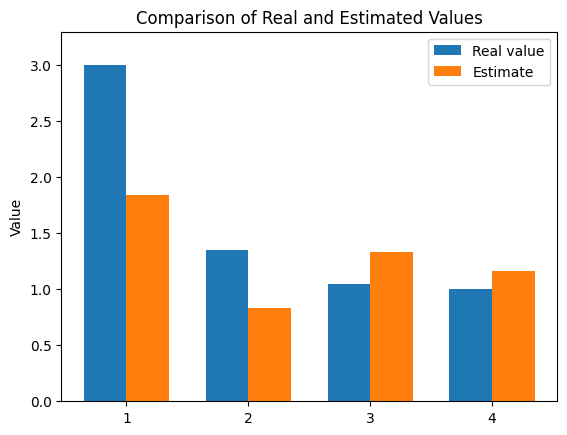

The function param_inverse took 574.642606 seconds.
| 2         | -0.3011   | 34.68     | 0.734     | 2.116     | 0.4665    |
Sampling 2 chains in parallel


2024-08-21 07:40:59,560	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.845  0.096   1.639    1.997      0.011    0.008      77.0      91.0   
x1  0.807  0.066   0.703    0.935      0.006    0.004     117.0     174.0   
x2  1.305  0.097   1.141    1.471      0.011    0.007      85.0     132.0   
x3  1.170  0.101   0.990    1.355      0.010    0.007     102.0     137.0   

    r_hat  
x0   1.03  
x1   1.02  
x2   1.03  
x3   1.03  
Estimated values are [1.845 0.807 1.305 1.17 ]
The difference between estimated values [1.155 0.543 0.255 0.17 ]



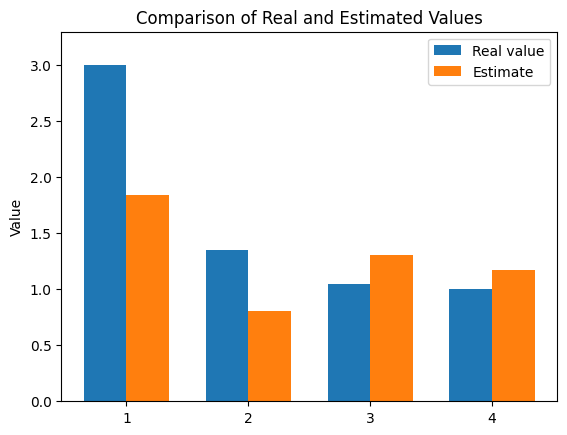

The function param_inverse took 597.586425 seconds.
| 3         | -0.3      | 48.03     | 1.562     | 2.041     | 0.4925    |
Sampling 2 chains in parallel


2024-08-21 07:51:13,560	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.848  0.107   1.671    2.060      0.011    0.008     106.0      97.0   
x1  0.831  0.074   0.699    0.969      0.006    0.004     139.0     159.0   
x2  1.321  0.090   1.154    1.474      0.008    0.006     130.0     139.0   
x3  1.156  0.110   0.964    1.387      0.011    0.008      94.0      95.0   

    r_hat  
x0   1.05  
x1   1.01  
x2   1.03  
x3   1.04  
Estimated values are [1.848 0.831 1.321 1.156]
The difference between estimated values [1.152 0.519 0.271 0.156]



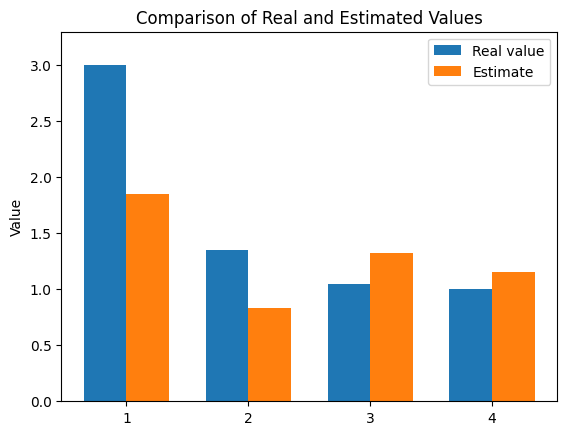

The function param_inverse took 608.804074 seconds.
| 4         | -0.2956   | 54.97     | 0.8185    | 2.364     | 0.2959    |
Sampling 2 chains in parallel


2024-08-21 08:01:04,477	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.850  0.107   1.629    2.018      0.011    0.007     105.0     189.0   
x1  0.863  0.086   0.686    1.014      0.009    0.007      84.0     203.0   
x2  1.388  0.088   1.218    1.544      0.008    0.006     116.0     183.0   
x3  1.140  0.126   0.912    1.391      0.011    0.008     125.0     211.0   

    r_hat  
x0   1.02  
x1   1.05  
x2   1.01  
x3   1.01  
Estimated values are [1.85  0.863 1.388 1.14 ]
The difference between estimated values [1.15  0.487 0.338 0.14 ]



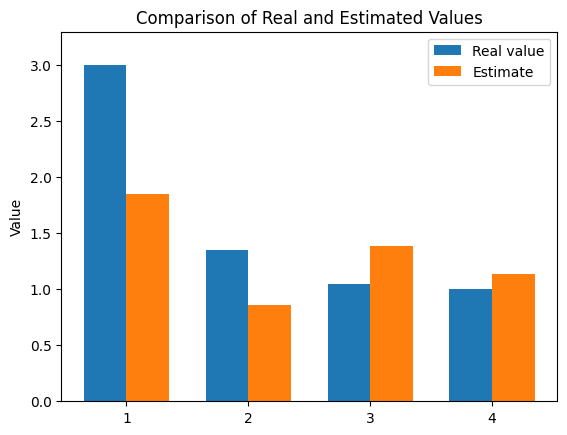

The function param_inverse took 593.629400 seconds.
| 5         | -0.3015   | 39.13     | 1.287     | 2.864     | 0.3228    |
Sampling 2 chains in parallel


2024-08-21 08:11:31,345	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.854  0.096   1.698    2.042      0.009    0.006     127.0     150.0   
x1  0.816  0.074   0.691    0.952      0.008    0.005      93.0     167.0   
x2  1.332  0.082   1.199    1.485      0.010    0.007      77.0     180.0   
x3  1.133  0.098   0.972    1.314      0.009    0.007     111.0     158.0   

    r_hat  
x0   1.01  
x1   1.02  
x2   1.05  
x3   1.02  
Estimated values are [1.854 0.816 1.332 1.133]
The difference between estimated values [1.146 0.534 0.282 0.133]



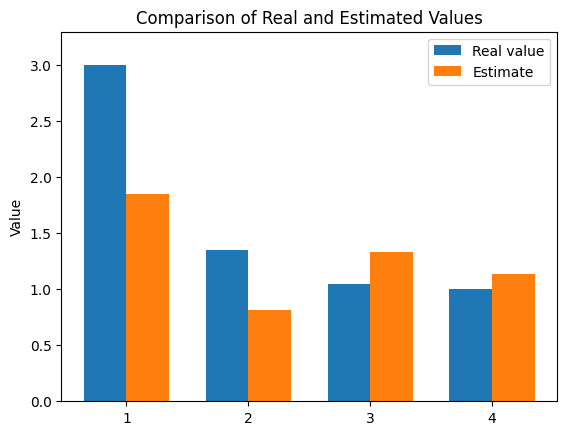

The function param_inverse took 624.860790 seconds.
| 6         | -0.2948   | 53.14     | 1.287     | 2.366     | 0.2722    |
Sampling 2 chains in parallel


2024-08-21 08:21:22,921	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.802  0.124   1.589    2.035      0.010    0.007     166.0     162.0   
x1  0.907  0.083   0.748    1.039      0.007    0.005     162.0     200.0   
x2  1.408  0.095   1.252    1.615      0.009    0.006     113.0     125.0   
x3  1.186  0.147   0.918    1.433      0.013    0.009     135.0     167.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.04  
x3   1.04  
Estimated values are [1.802 0.907 1.408 1.186]
The difference between estimated values [1.198 0.443 0.358 0.186]



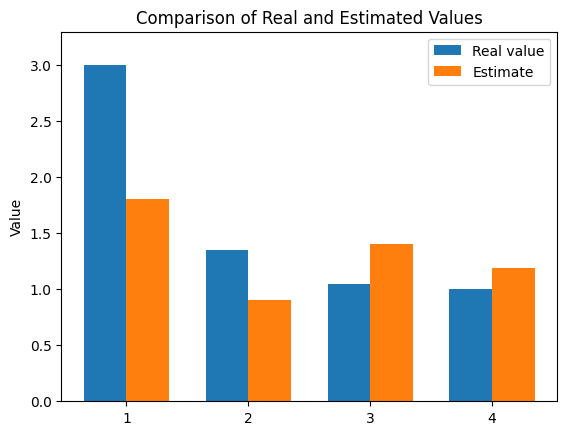

The function param_inverse took 591.024709 seconds.
| 7         | -0.3136   | 60.0      | 2.0       | 4.0       | 0.4795    |
Sampling 2 chains in parallel


2024-08-21 08:31:02,164	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.871  0.139   1.658    2.177      0.015    0.010      85.0     186.0   
x1  0.917  0.083   0.769    1.068      0.010    0.007      76.0     213.0   
x2  1.398  0.093   1.257    1.619      0.008    0.005     146.0     193.0   
x3  1.138  0.153   0.849    1.424      0.017    0.012      89.0     169.0   

    r_hat  
x0   1.03  
x1   1.03  
x2   1.04  
x3   1.03  
Estimated values are [1.871 0.917 1.398 1.138]
The difference between estimated values [1.129 0.433 0.348 0.138]



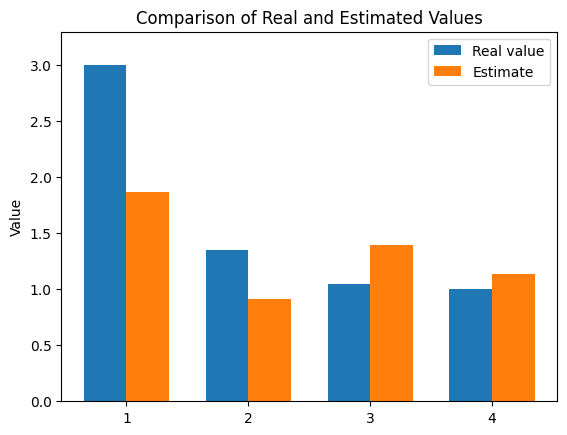

The function param_inverse took 579.603505 seconds.
| 8         | -0.2916   | 51.37     | 0.5       | 4.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-21 08:40:51,957	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.929  0.213   1.582    2.372      0.021    0.015     105.0     117.0   
x1  0.957  0.094   0.802    1.138      0.007    0.005     163.0     245.0   
x2  1.460  0.104   1.274    1.649      0.010    0.007     103.0     166.0   
x3  1.150  0.241   0.619    1.517      0.024    0.017     105.0     156.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.02  
x3   1.02  
Estimated values are [1.929 0.957 1.46  1.15 ]
The difference between estimated values [1.071 0.393 0.41  0.15 ]



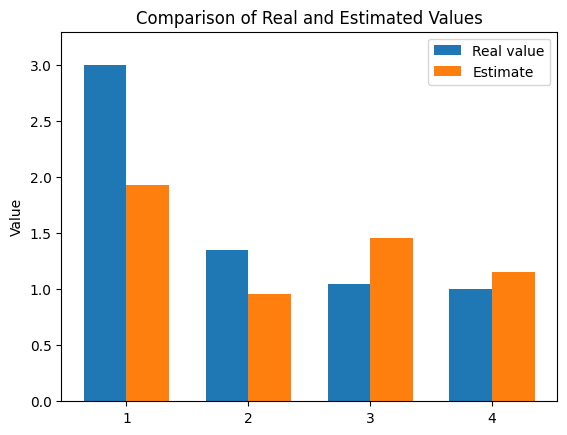

The function param_inverse took 566.756517 seconds.
| 9         | -0.2971   | 30.0      | 2.0       | 4.0       | 0.25      |
Sampling 2 chains in parallel


2024-08-21 08:50:34,202	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.838  0.155   1.510    2.091      0.017    0.012      78.0     124.0   
x1  0.900  0.093   0.750    1.081      0.009    0.006     120.0     166.0   
x2  1.413  0.102   1.254    1.635      0.010    0.007      98.0     100.0   
x3  1.162  0.187   0.861    1.530      0.021    0.015      81.0      96.0   

    r_hat  
x0   1.04  
x1   1.01  
x2   1.04  
x3   1.02  
Estimated values are [1.838 0.9   1.413 1.162]
The difference between estimated values [1.162 0.45  0.363 0.162]



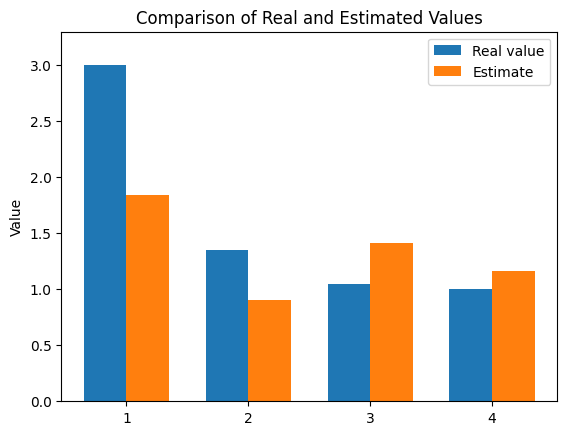

The function param_inverse took 606.770856 seconds.
| 10        | -0.3071   | 53.52     | 0.5       | 4.0       | 0.5       |
Sampling 2 chains in parallel


2024-08-21 09:01:09,017	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.836  0.101   1.657    2.051      0.014    0.010      52.0     118.0   
x1  0.817  0.075   0.671    0.951      0.006    0.005     139.0     175.0   
x2  1.330  0.088   1.179    1.492      0.016    0.011      34.0     173.0   
x3  1.166  0.119   0.956    1.386      0.012    0.009      96.0      96.0   

    r_hat  
x0   1.06  
x1   1.01  
x2   1.07  
x3   1.02  
Estimated values are [1.836 0.817 1.33  1.166]
The difference between estimated values [1.164 0.533 0.28  0.166]



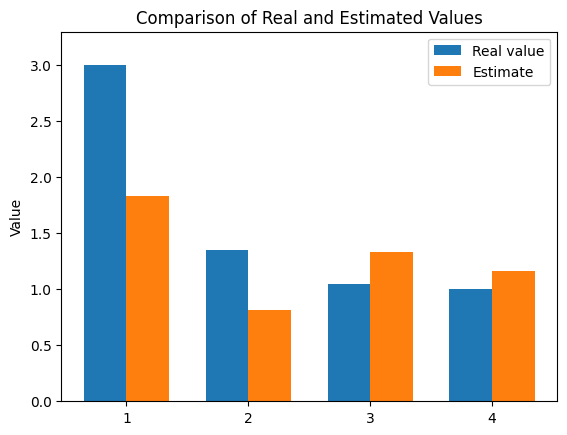

The function param_inverse took 634.966371 seconds.
| 11        | -0.3039   | 58.11     | 1.626     | 2.58      | 0.4675    |
Sampling 2 chains in parallel


2024-08-21 09:11:04,055	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.851  0.131   1.577    2.077      0.014    0.010      86.0     126.0   
x1  0.859  0.083   0.701    0.997      0.008    0.005     124.0     132.0   
x2  1.400  0.090   1.240    1.558      0.009    0.006     112.0     132.0   
x3  1.151  0.147   0.903    1.430      0.015    0.010     102.0     131.0   

    r_hat  
x0   1.03  
x1   1.01  
x2   1.02  
x3   1.03  
Estimated values are [1.851 0.859 1.4   1.151]
The difference between estimated values [1.149 0.491 0.35  0.151]



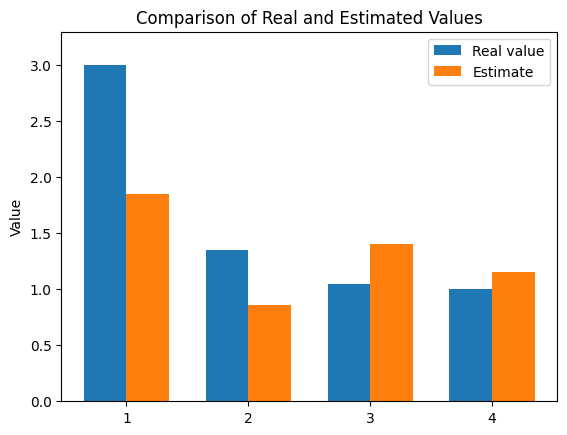

The function param_inverse took 597.340881 seconds.
| 12        | -0.3078   | 37.48     | 1.715     | 2.735     | 0.4766    |
Sampling 2 chains in parallel


2024-08-21 09:21:37,675	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.833  0.134   1.612    2.104      0.013    0.009     120.0     131.0   
x1  0.912  0.086   0.770    1.084      0.007    0.005     143.0     248.0   
x2  1.412  0.086   1.264    1.572      0.008    0.005     129.0     208.0   
x3  1.169  0.174   0.817    1.471      0.019    0.014      80.0     159.0   

    r_hat  
x0   1.04  
x1   1.01  
x2   1.03  
x3   1.02  
Estimated values are [1.833 0.912 1.412 1.169]
The difference between estimated values [1.167 0.438 0.362 0.169]



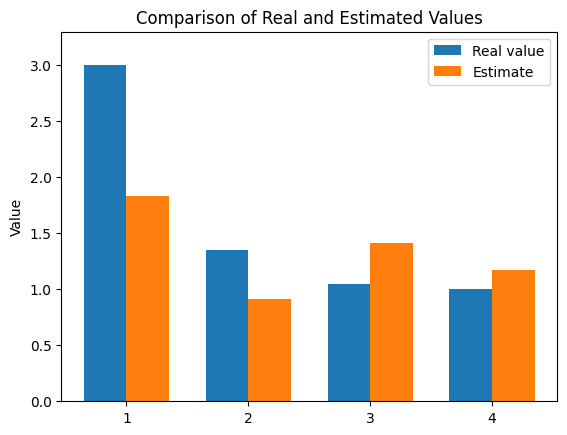

The function param_inverse took 633.535285 seconds.
| 13        | -0.3068   | 34.07     | 0.632     | 3.064     | 0.2777    |
Sampling 2 chains in parallel


2024-08-21 09:31:53,370	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.831  0.098   1.627    1.977      0.009    0.007     107.0     156.0   
x1  0.807  0.073   0.668    0.926      0.008    0.006      88.0     127.0   
x2  1.323  0.085   1.154    1.451      0.008    0.006     110.0     128.0   
x3  1.160  0.104   0.990    1.381      0.010    0.007     102.0     129.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.03  
x3   1.04  
Estimated values are [1.831 0.807 1.323 1.16 ]
The difference between estimated values [1.169 0.543 0.273 0.16 ]



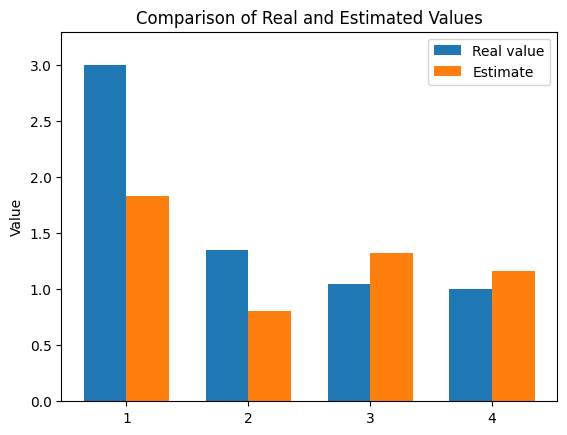

The function param_inverse took 613.012853 seconds.
| 14        | -0.303    | 57.64     | 0.791     | 2.293     | 0.3434    |
Sampling 2 chains in parallel


2024-08-21 09:41:52,048	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.814  0.124   1.573    2.036      0.014    0.010      72.0      92.0   
x1  0.898  0.093   0.723    1.078      0.010    0.007      93.0     125.0   
x2  1.389  0.095   1.192    1.535      0.011    0.008      77.0     161.0   
x3  1.181  0.143   0.915    1.441      0.015    0.013      75.0     204.0   

    r_hat  
x0   1.03  
x1   1.01  
x2   1.02  
x3   1.04  
Estimated values are [1.814 0.898 1.389 1.181]
The difference between estimated values [1.186 0.452 0.339 0.181]



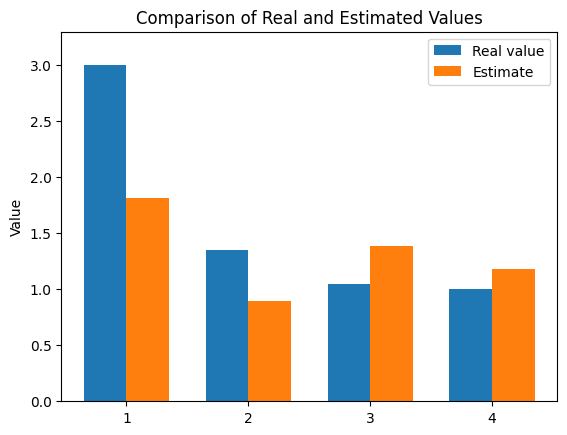

The function param_inverse took 602.452672 seconds.
| 15        | -0.3085   | 51.48     | 0.7492    | 3.483     | 0.25      |
Sampling 2 chains in parallel


2024-08-21 09:52:18,283	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.866  0.094   1.711    2.041      0.009    0.006     112.0     203.0   
x1  0.810  0.070   0.691    0.946      0.006    0.004     161.0     187.0   
x2  1.300  0.092   1.109    1.448      0.010    0.007      82.0      93.0   
x3  1.136  0.101   0.965    1.339      0.009    0.006     123.0     140.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.02  
x3   1.02  
Estimated values are [1.866 0.81  1.3   1.136]
The difference between estimated values [1.134 0.54  0.25  0.136]



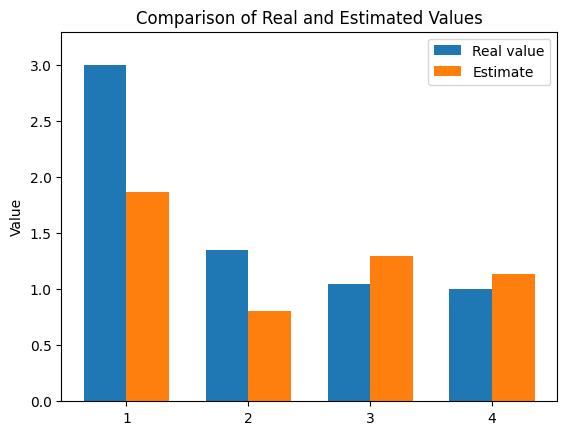

The function param_inverse took 625.578035 seconds.
| 16        | -0.288    | 59.42     | 1.218     | 2.311     | 0.2902    |
Sampling 2 chains in parallel


2024-08-21 10:02:41,367	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.846  0.098   1.627    2.015      0.009    0.006     119.0     113.0   
x1  0.837  0.076   0.686    0.965      0.007    0.005     130.0     189.0   
x2  1.342  0.097   1.187    1.535      0.010    0.007     102.0     175.0   
x3  1.147  0.106   0.971    1.345      0.010    0.007     109.0     190.0   

    r_hat  
x0   1.02  
x1   1.01  
x2   1.02  
x3   1.03  
Estimated values are [1.846 0.837 1.342 1.147]
The difference between estimated values [1.154 0.513 0.292 0.147]



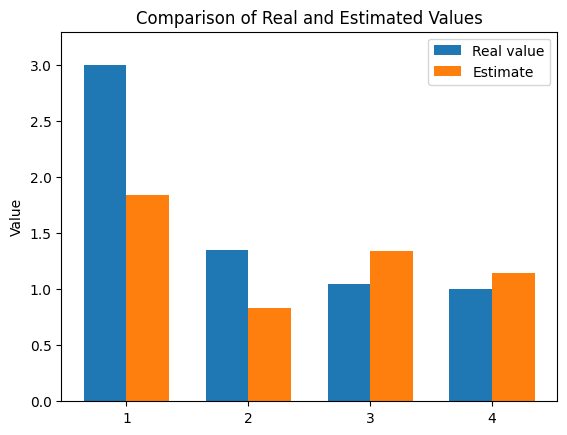

The function param_inverse took 628.064624 seconds.
| 17        | -0.2974   | 56.24     | 0.8244    | 2.787     | 0.416     |
Sampling 2 chains in parallel


2024-08-21 10:12:55,315	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.844  0.099   1.643    2.035      0.015    0.011      48.0      68.0   
x1  0.818  0.083   0.648    0.940      0.011    0.008      55.0      88.0   
x2  1.347  0.097   1.186    1.526      0.011    0.008      70.0     123.0   
x3  1.162  0.117   0.920    1.348      0.017    0.012      48.0      89.0   

    r_hat  
x0   1.04  
x1   1.02  
x2   1.04  
x3   1.02  
Estimated values are [1.844 0.818 1.347 1.162]
The difference between estimated values [1.156 0.532 0.297 0.162]



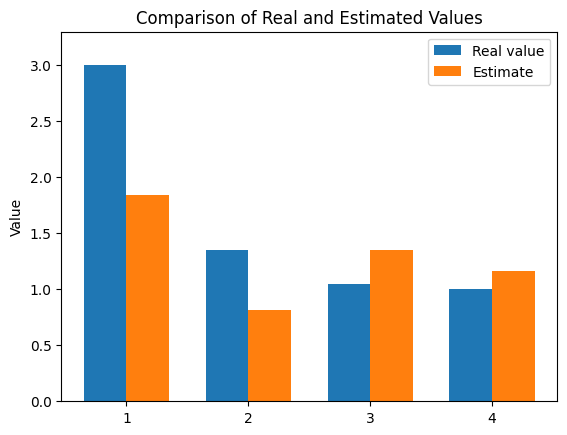

The function param_inverse took 656.549985 seconds.
| 18        | -0.3061   | 33.91     | 1.306     | 2.054     | 0.2545    |
Sampling 2 chains in parallel


2024-08-21 10:24:13,357	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.867  0.169   1.633    2.228      0.023    0.016      57.0      46.0   
x1  0.935  0.089   0.742    1.077      0.008    0.005     133.0     117.0   
x2  1.434  0.101   1.246    1.608      0.011    0.008      99.0     132.0   
x3  1.172  0.217   0.770    1.535      0.026    0.018      69.0      79.0   

    r_hat  
x0   1.03  
x1   1.04  
x2   1.01  
x3   1.03  
Estimated values are [1.867 0.935 1.434 1.172]
The difference between estimated values [1.133 0.415 0.384 0.172]



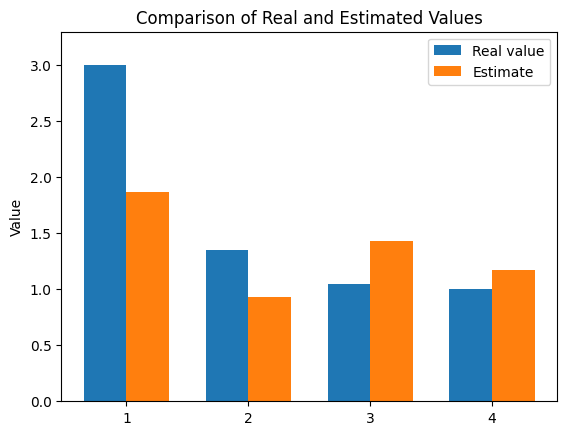

The function param_inverse took 625.546863 seconds.
| 19        | -0.3057   | 32.97     | 1.715     | 3.608     | 0.4938    |
Sampling 2 chains in parallel


2024-08-21 10:34:45,106	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.850  0.129   1.624    2.088      0.012    0.009     116.0     147.0   
x1  0.901  0.096   0.736    1.072      0.011    0.008      75.0     159.0   
x2  1.393  0.095   1.217    1.550      0.009    0.007     110.0     211.0   
x3  1.143  0.161   0.844    1.483      0.018    0.012      88.0     112.0   

    r_hat  
x0   1.01  
x1   1.04  
x2   1.02  
x3   1.02  
Estimated values are [1.85  0.901 1.393 1.143]
The difference between estimated values [1.15  0.449 0.343 0.143]



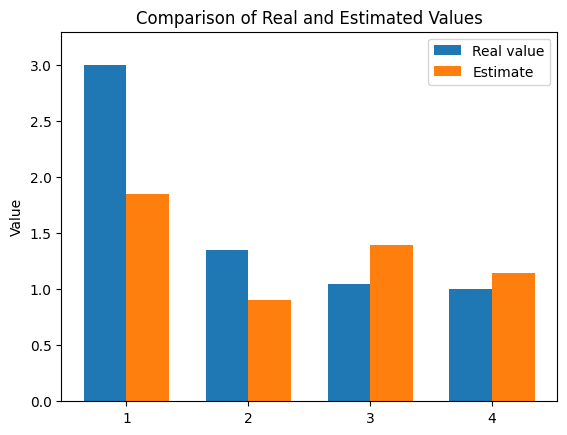

The function param_inverse took 662.652426 seconds.
| 20        | -0.2964   | 55.72     | 1.365     | 3.844     | 0.311     |
Sampling 2 chains in parallel


2024-08-21 10:45:41,982	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.826  0.103   1.648    2.000      0.011    0.008      82.0     130.0   
x1  0.842  0.073   0.699    0.957      0.006    0.005     131.0     187.0   
x2  1.342  0.075   1.185    1.462      0.009    0.006      81.0     171.0   
x3  1.165  0.115   0.953    1.374      0.014    0.010      71.0     125.0   

    r_hat  
x0   1.04  
x1   1.01  
x2   1.05  
x3   1.04  
Estimated values are [1.826 0.842 1.342 1.165]
The difference between estimated values [1.174 0.508 0.292 0.165]



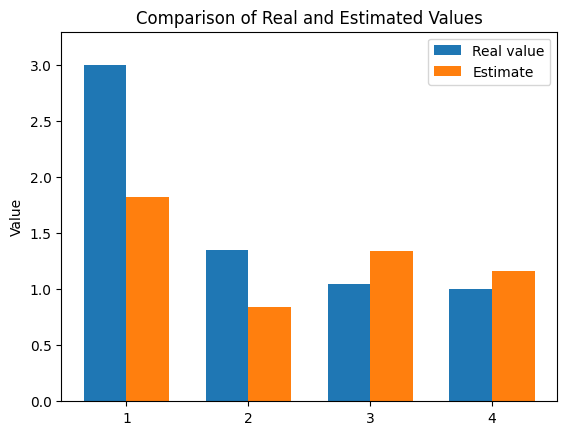

The function param_inverse took 616.398247 seconds.
| 21        | -0.3027   | 55.0      | 1.145     | 2.496     | 0.314     |
Sampling 2 chains in parallel


2024-08-21 10:55:33,715	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.819  0.101   1.649    2.015      0.010    0.007     112.0     128.0   
x1  0.856  0.076   0.732    0.996      0.006    0.005     136.0     228.0   
x2  1.375  0.089   1.222    1.544      0.008    0.005     137.0     192.0   
x3  1.161  0.114   0.926    1.338      0.011    0.008     104.0     194.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.02  
x3   1.02  
Estimated values are [1.819 0.856 1.375 1.161]
The difference between estimated values [1.181 0.494 0.325 0.161]



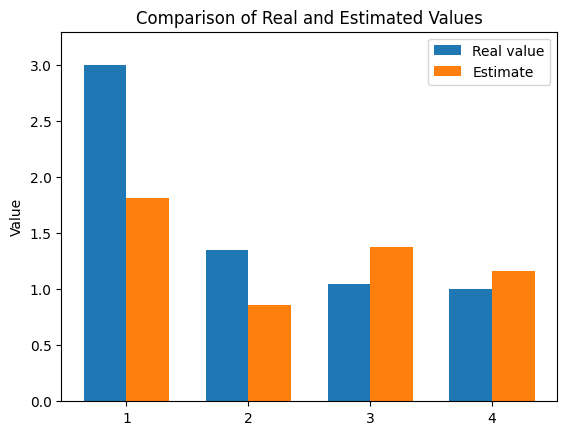

The function param_inverse took 625.152848 seconds.
| 22        | -0.3075   | 52.93     | 1.15      | 2.671     | 0.3851    |
Sampling 2 chains in parallel


2024-08-21 11:06:22,195	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.847  0.106   1.659    2.061      0.010    0.007     114.0     144.0   
x1  0.847  0.073   0.710    0.972      0.006    0.004     167.0     238.0   
x2  1.356  0.095   1.176    1.516      0.010    0.007      85.0     116.0   
x3  1.141  0.116   0.928    1.356      0.012    0.008     100.0     106.0   

    r_hat  
x0   1.03  
x1   1.01  
x2   1.02  
x3   1.02  
Estimated values are [1.847 0.847 1.356 1.141]
The difference between estimated values [1.153 0.503 0.306 0.141]



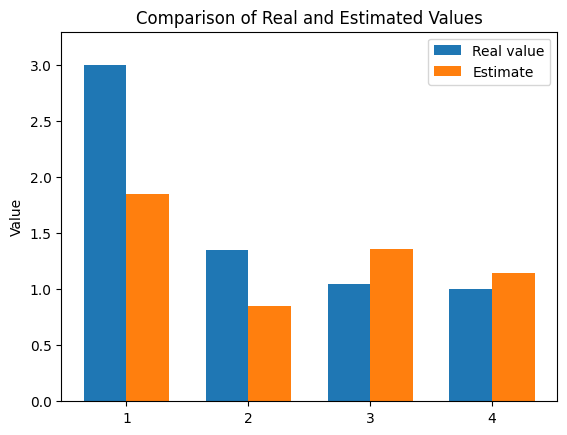

The function param_inverse took 616.867626 seconds.
| 23        | -0.2973   | 57.1      | 1.538     | 2.938     | 0.2803    |
Sampling 2 chains in parallel


2024-08-21 11:16:35,411	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.857  0.159   1.612    2.187      0.014    0.010     138.0     208.0   
x1  0.933  0.097   0.760    1.109      0.009    0.006     118.0     213.0   
x2  1.431  0.098   1.253    1.616      0.008    0.005     166.0     152.0   
x3  1.165  0.197   0.792    1.526      0.016    0.012     145.0     172.0   

    r_hat  
x0   1.01  
x1   1.03  
x2   1.01  
x3   1.00  
Estimated values are [1.857 0.933 1.431 1.165]
The difference between estimated values [1.143 0.417 0.381 0.165]



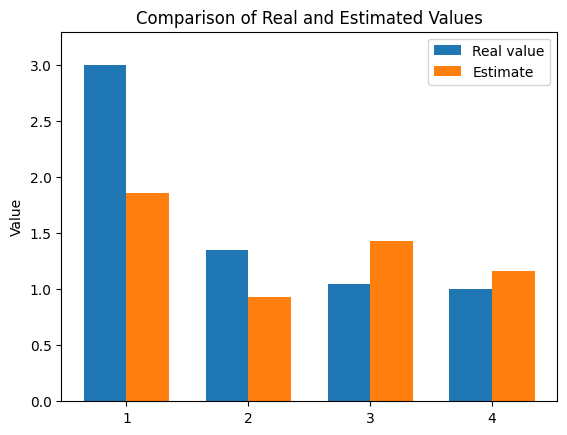

The function param_inverse took 653.578436 seconds.
| 24        | -0.3044   | 44.05     | 1.208     | 3.922     | 0.4252    |
Sampling 2 chains in parallel


2024-08-21 11:27:05,732	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.846  0.151   1.568    2.119      0.014    0.010     118.0     176.0   
x1  0.918  0.097   0.734    1.100      0.009    0.007     105.0     146.0   
x2  1.413  0.092   1.255    1.590      0.008    0.005     147.0     163.0   
x3  1.164  0.178   0.852    1.516      0.016    0.012     118.0     147.0   

    r_hat  
x0   1.03  
x1   1.02  
x2   1.03  
x3   1.02  
Estimated values are [1.846 0.918 1.413 1.164]
The difference between estimated values [1.154 0.432 0.363 0.164]



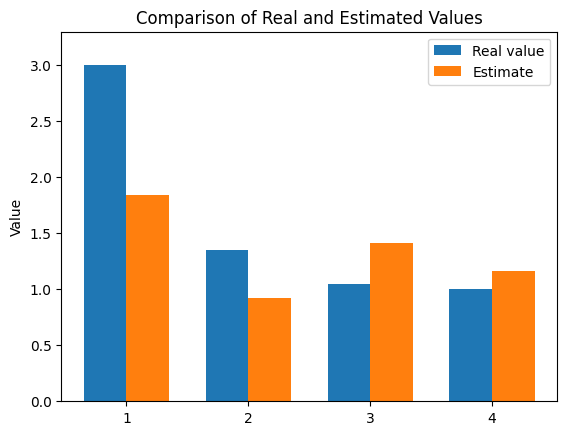

The function param_inverse took 613.804005 seconds.
| 25        | -0.3036   | 47.34     | 0.7909    | 3.993     | 0.4158    |
Sampling 2 chains in parallel


2024-08-21 11:37:49,646	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.904  0.189   1.564    2.211      0.020    0.014      90.0      90.0   
x1  0.940  0.103   0.768    1.141      0.012    0.008      77.0     121.0   
x2  1.438  0.108   1.249    1.668      0.012    0.008      87.0     129.0   
x3  1.101  0.233   0.647    1.506      0.027    0.020      79.0      66.0   

    r_hat  
x0   1.02  
x1   1.07  
x2   1.03  
x3   1.03  
Estimated values are [1.904 0.94  1.438 1.101]
The difference between estimated values [1.096 0.41  0.388 0.101]



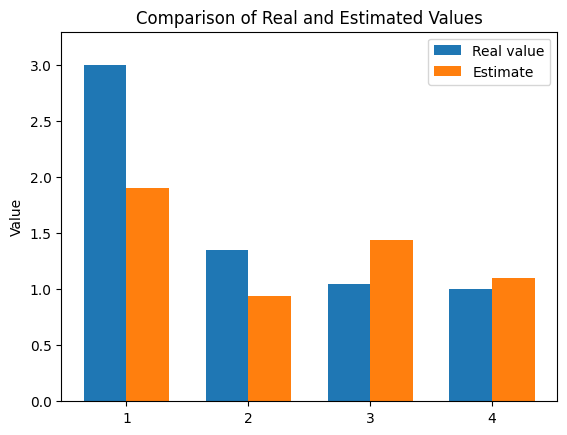

The function param_inverse took 662.093285 seconds.
| 26        | -0.2849   | 30.74     | 1.218     | 3.513     | 0.3815    |
Sampling 2 chains in parallel


2024-08-21 11:48:34,807	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.884  0.173   1.613    2.259      0.015    0.011     135.0     190.0   
x1  0.919  0.098   0.753    1.105      0.009    0.007     120.0     144.0   
x2  1.446  0.094   1.268    1.611      0.010    0.007     100.0     134.0   
x3  1.143  0.191   0.834    1.520      0.016    0.011     145.0     137.0   

    r_hat  
x0   1.02  
x1   1.02  
x2   1.03  
x3   1.01  
Estimated values are [1.884 0.919 1.446 1.143]
The difference between estimated values [1.116 0.431 0.396 0.143]



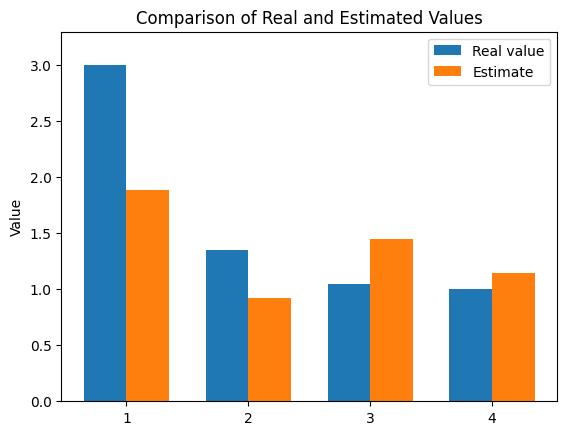

The function param_inverse took 612.844424 seconds.
| 27        | -0.3029   | 30.74     | 1.218     | 3.513     | 0.3815    |
Sampling 2 chains in parallel


2024-08-21 11:59:22,723	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.818  0.136   1.589    2.100      0.013    0.009     106.0     164.0   
x1  0.922  0.091   0.760    1.088      0.008    0.006     125.0     135.0   
x2  1.419  0.084   1.267    1.563      0.007    0.005     150.0     159.0   
x3  1.202  0.179   0.908    1.534      0.016    0.012     118.0     165.0   

    r_hat  
x0   1.03  
x1   1.01  
x2   1.01  
x3   1.03  
Estimated values are [1.818 0.922 1.419 1.202]
The difference between estimated values [1.182 0.428 0.369 0.202]



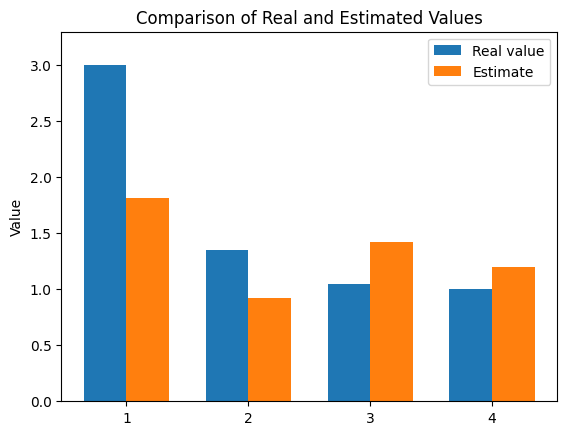

The function param_inverse took 727.987906 seconds.
| 28        | -0.3161   | 33.81     | 0.8165    | 3.257     | 0.493     |
Sampling 2 chains in parallel


2024-08-21 12:11:47,971	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.845  0.107   1.653    2.014      0.013    0.009      77.0     128.0   
x1  0.812  0.074   0.687    0.953      0.007    0.005     110.0     103.0   
x2  1.326  0.092   1.178    1.501      0.009    0.007     101.0     111.0   
x3  1.149  0.103   0.973    1.330      0.010    0.007     108.0      97.0   

    r_hat  
x0   1.05  
x1   1.02  
x2   1.01  
x3   1.02  
Estimated values are [1.845 0.812 1.326 1.149]
The difference between estimated values [1.155 0.538 0.276 0.149]



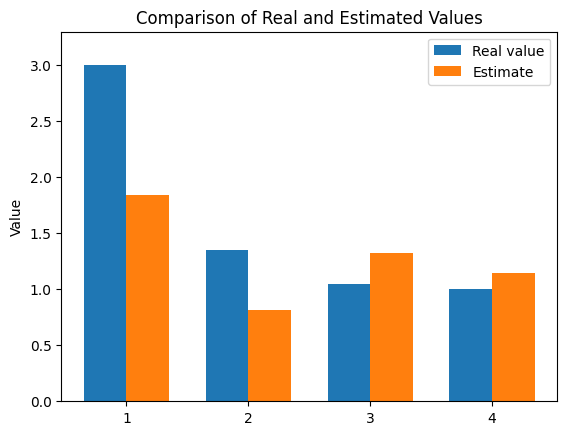

The function param_inverse took 692.506761 seconds.
| 29        | -0.2988   | 53.72     | 1.352     | 2.233     | 0.4101    |
Sampling 2 chains in parallel


2024-08-21 12:23:06,582	INFO worker.py:1621 -- Calling ray.init() again after it has already been called.


     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.831  0.114   1.599    2.012      0.011    0.008     106.0      93.0   
x1  0.845  0.077   0.668    0.966      0.007    0.005     126.0     122.0   
x2  1.354  0.085   1.181    1.503      0.007    0.005     154.0     124.0   
x3  1.169  0.127   0.948    1.423      0.011    0.008     126.0     131.0   

    r_hat  
x0   1.03  
x1   1.02  
x2   1.01  
x3   1.03  
Estimated values are [1.831 0.845 1.354 1.169]
The difference between estimated values [1.169 0.505 0.304 0.169]



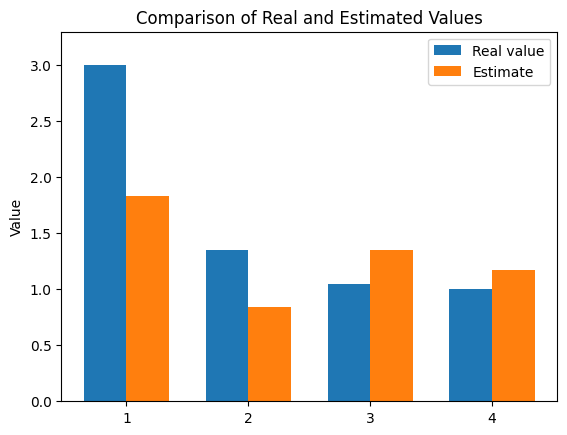

The function param_inverse took 674.683630 seconds.
| 30        | -0.3056   | 37.17     | 1.988     | 2.248     | 0.3292    |


In [20]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,60)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( 2.,4.)
rwmh_scaling_bounds =  (0.5,2.)
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "DREAMZ"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF= HPO_tinyDA(datahf=datatest, 
                                                    mean_prior=mean_prior, 
                                                    cov_prior=cov_prior, 
                                                    domain=(0.,7.),
                                                    Yhf=np.array(y_test).reshape(-1,2), 
                                                    sigma_noise_bounds=sigma_noise_bounds, 
                                                    n_data_bounds=n_data_bounds,
                                                    parameters=parameters, 
                                                    sigma_bounds=sigma_bounds,
                                                    rwmh_scaling_bounds=rwmh_scaling_bounds, 
                                                    rwmh_cov=rwmh_cov, 
                                                    rwmh_adaptive=rwmh_adaptive, 
                                                    iterations=iterations, 
                                                    burnin=burnin, 
                                                    n_chains= n_chains, 
                                                    final_model=final_model,
                                                    levels=1, 
                                                    algo=algo, 
                                                    force_sequential=False)

In [ ]:
mean_prior =np.array([2.5,1.,1.5,1.5])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise_bounds = (0.25,0.5)
n_data_bounds = (30,60)
parameters =np.array([3.,1.35,1.05,1.])
sigma_bounds = ( 2.,4.)
rwmh_scaling_bounds =  (0.5,2.)
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"





module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)


sigma_noise_MF, n_data_MF, sigma_MF, rwmh_scaling_MF= HPO_tinyDA(datahf=datatest, 
                                                    mean_prior=mean_prior, 
                                                    cov_prior=cov_prior, 
                                                    domain=(0.,7.),
                                                    Yhf=np.array(y_test).reshape(-1,2), 
                                                    sigma_noise_bounds=sigma_noise_bounds, 
                                                    n_data_bounds=n_data_bounds,
                                                    parameters=parameters, 
                                                    sigma_bounds=sigma_bounds,
                                                    rwmh_scaling_bounds=rwmh_scaling_bounds, 
                                                    rwmh_cov=rwmh_cov, 
                                                    rwmh_adaptive=rwmh_adaptive, 
                                                    iterations=iterations, 
                                                    burnin=burnin, 
                                                    n_chains= n_chains, 
                                                    final_model=final_model,
                                                    levels=1, 
                                                    algo=algo, 
                                                    force_sequential=False)

In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 30
burnin = 20
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, subsampling_rate=5,levels=3,force_sequential=True)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "AM"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, force_sequential=True)


In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "DREAMZ"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo, force_sequential=True)

In [ ]:
mean_prior =np.array([2.3,0.9,0.4,1.1])
cov_prior=np.diag([ 0.1, 0.01, 0.01, 0.1])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters =np.array([3.,1.2,1.35,1.825])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

estimateMF, errorMF, param_resultsMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo,force_sequential=True)
